### Import thư viện cần thiết

In [53]:
!pip install skorch

In [54]:
# Nhóm thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Nhóm thư viện học máy
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Nhóm thư viện Pytorch
import torch # Thư viện chính của Pytorch
import torch.nn as nn # Module chứa các thành phần xây dựng mạng (lớp, loss, activation)
import torch.optim as optim # Chứa các thuật toán tối ưu (SGD, Adam...)
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from skorch import NeuralNetClassifier #skorch: thư viện wrapper - biến mô hình pytorch thành estimator theo chuẩn sklearn

# Nhóm thư viện Tensorflow
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import AUC

# Nhóm thư viện xử lý mất cân bằng
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


###1. Đọc và khám phá dữ liệu

In [55]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Sau khi mount, bạn có thể truy cập file trong Drive tại:
# /content/drive/MyDrive/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import pandas as pd

# Đường dẫn tới file
file_path = '/content/drive/MyDrive/creditcard.csv'

# Đọc file CSV vào dataframe
df = pd.read_csv(file_path)

# Kiểm tra vài dòng đầu tiên
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [57]:
import pandas as pd

def read_and_explore_data(file_path, show = False):
    print("1. Đọc và khám phá dữ liệu")
    print("-"*100)

    #1.1 Đọc dữ liệu
    df = pd.read_csv(file_path)
    print(f"Kích thước dữ liệu: {df.shape}")

    if show:
        #1.2 Xem thông tin dữ liệu
        print('-'*100)
        print("Thông tin dữ liệu:")
        print(df.info())
        print('-'*100)

        #1.3 Kiểm tra giá trị thiếu Missing Value
        print("Kiểm tra giá trị thiếu:")
        missing_values = df.isnull().sum()

        # conditional expression: Toán tử ba ngôi (ternary operator)
        print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Không có giá trị Missing Value")

        # 1.4 Thống kê mô tả
        print('-'*100)
        print("Thống kê mô tả:")
        display(df.describe())

        # 1.5 Kiểm tra phân phối nhãn
        print('-'*100)
        print("Kiểm tra phân phối nhãn (Fraud vs Non - Fraud):")
        fraud_count = df['Class'].value_counts()
        print(fraud_count)

        # Kiểm tra phân phối nhãn theo tỉ lệ
        print(f"Phần trăm nhãn Non - Fraud: {100*fraud_count[0]/len(df)} %")
        print(f"Phần trăm nhãn Fraud: {100*fraud_count[1]/len(df)} %")

    return df


df = read_and_explore_data(file_path, show = True)

1. Đọc và khám phá dữ liệu
----------------------------------------------------------------------------------------------------
Kích thước dữ liệu: (284807, 31)
----------------------------------------------------------------------------------------------------
Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


----------------------------------------------------------------------------------------------------
Kiểm tra phân phối nhãn (Fraud vs Non - Fraud):
Class
0    284315
1       492
Name: count, dtype: int64
Phần trăm nhãn Non - Fraud: 99.827251436938 %
Phần trăm nhãn Fraud: 0.1727485630620034 %


In [58]:
df.columns #Kiểm tra các feature của dataset

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

#### Chuyển time sang giờ


In [59]:
# 1. Trích xuất đặc trưng 'Hour' (Dùng phép chia lấy nguyên // cho an toàn)
df['Hour'] = (df['Time'] // 3600) % 24

# 2. Xóa bỏ cột 'Time' gốc khỏi DataFrame
df.drop('Time', axis=1, inplace=True)

# 3. Hiển thị thống kê mô tả của cột 'Hour' mới tạo
print(df['Hour'].describe())

count    284807.000000
mean         14.046470
std           5.835854
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64


In [60]:
df['Amount'].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


In [61]:
df.columns #Kiểm tra các đặc trung sau khi thêm fetures Hour

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class',
       'Hour'],
      dtype='object')

In [62]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0


### 2. Phân tích dữ liệu và trực quan hóa
- Biến mục tiêu
- Amount (Tiền giao dịch)
- Time (Thời gian giao dịch)
- Đặc trung PCA

#### Phân tích biến mục tiêu

PHÂN TÍCH BIẾN MỤC TIÊU (CLASS)
--------------------------------------------------


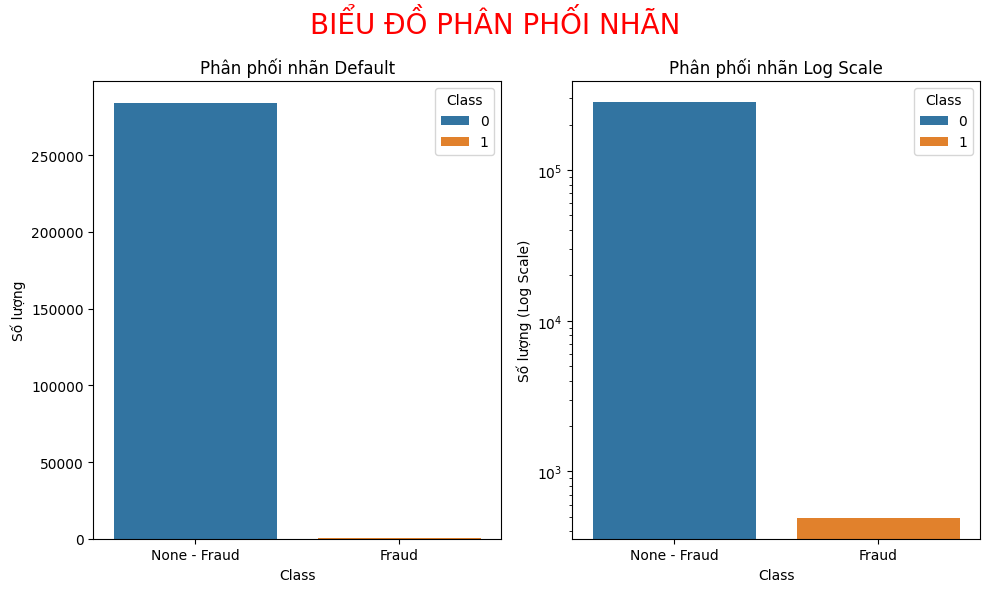

In [63]:
# 2.1. Phân tích và trực quan hóa biến mục tiêu
print("PHÂN TÍCH BIẾN MỤC TIÊU (CLASS)")
print("-" * 50)

fig1 = plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Class', hue='Class')
plt.title("Phân phối nhãn Default")
plt.xlabel("Class")
plt.ylabel("Số lượng")
plt.xticks([0, 1], ['None - Fraud', 'Fraud'])

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Class', hue='Class')
plt.title("Phân phối nhãn Log Scale")
plt.xlabel("Class")
plt.ylabel("Số lượng (Log Scale)")
plt.yscale('log')
plt.xticks([0, 1], ['None - Fraud', 'Fraud'])

fig1.suptitle("BIỂU ĐỒ PHÂN PHỐI NHÃN", fontsize=20, color='red')
plt.tight_layout()
plt.show()

### 💡 Insight 1:
* Sự thật từ dữ liệu: Tỷ lệ giao dịch gian lận cực kỳ hiếm, chỉ chiếm khoảng ~0.17%(394/284,807) tổng số giao dịch
* Hệ quả:Mô hình dễ bị "mù" và thiên vị lớp đa số. Thước đo Accuracy (Độ chính xác) trở nên vô nghĩa

==> Bắt buộc phải sử dụng các kỹ thuật cân bằng dữ liệu (SMOTE, Undersampling) và dùng các thước đo thay thế như **PR-AUC, Recall, F1-Score** để đánh giá

#### Phân tích biến Amonut

PHÂN TÍCH CỘT AMOUNT
--------------------------------------------------


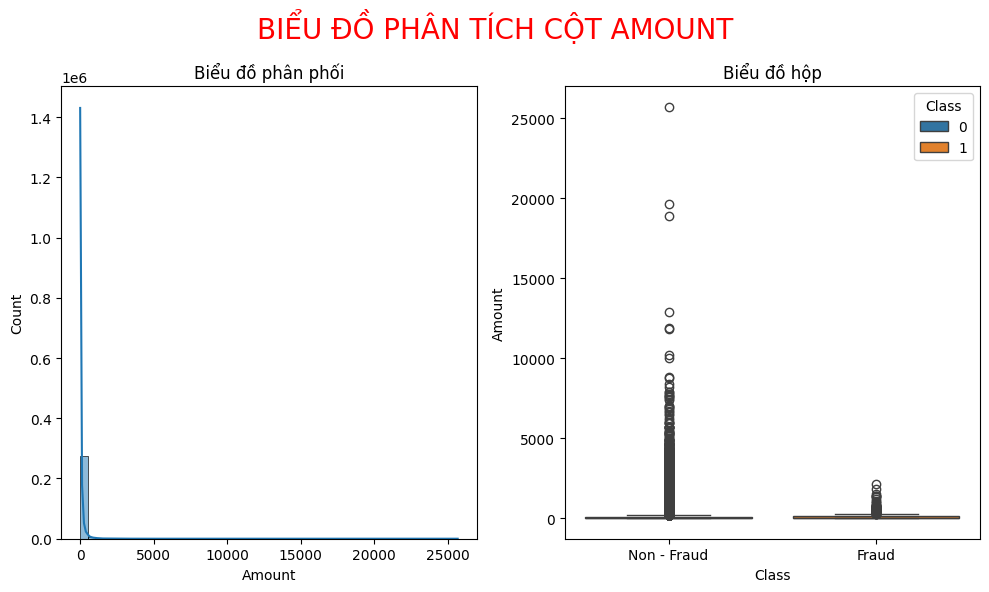

In [64]:
# 2.2. Phân tích và trực quan hóa cột Amount
print("PHÂN TÍCH CỘT AMOUNT")
print("-" * 50)

fig2 = plt.figure(figsize=(10, 6))

# Biểu đồ histogram
plt.subplot(1, 2, 1)
sns.histplot(data=df['Amount'], bins=50, kde=True)
plt.title("Biểu đồ phân phối")

# Biểu đồ box
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Class', y='Amount', hue='Class')
plt.title("Biểu đồ hộp")
plt.xticks([0, 1], ['Non - Fraud', 'Fraud'])

fig2.suptitle("BIỂU ĐỒ PHÂN TÍCH CỘT AMOUNT", fontsize=20, color='red')
plt.tight_layout()
plt.show()

#### Phân tích biến Time

PHÂN TÍCH TẦN SUẤT GIAO DỊCH THEO GIỜ
--------------------------------------------------


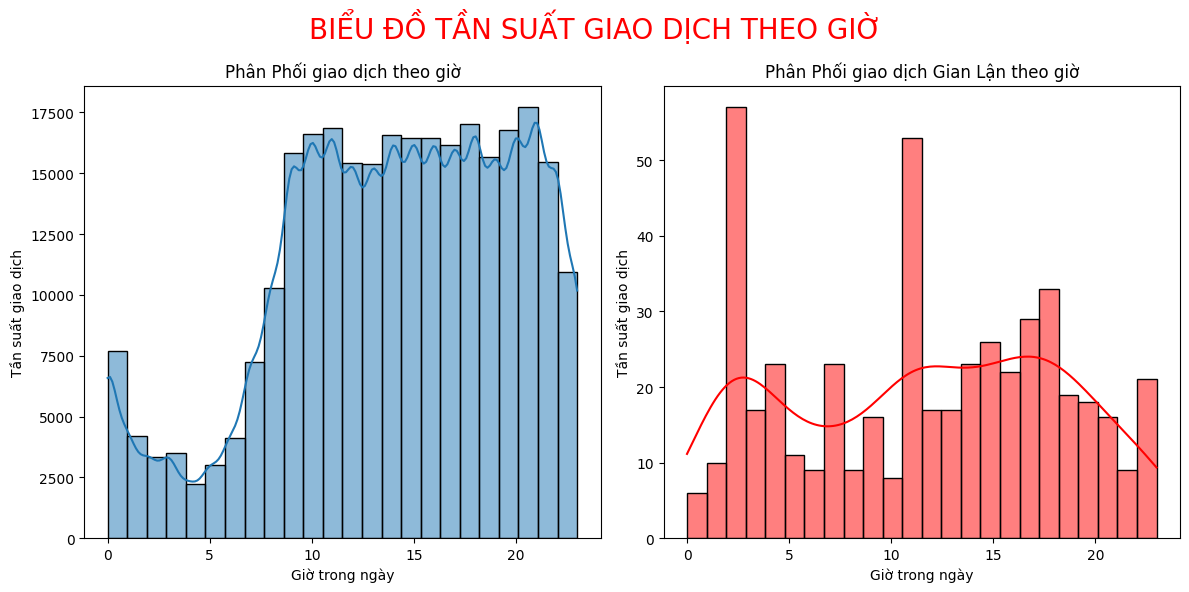

In [65]:
# 2.3. Phân tích và trực quan hóa cột Time
print("PHÂN TÍCH TẦN SUẤT GIAO DỊCH THEO GIỜ")
print("-" * 50)

# Tạo cột 'Hour' trong df nếu chưa có
if 'Hour' not in df.columns:
    df['Hour'] = df['Time'] / 3600 % 24

fig3 = plt.figure(figsize=(12, 6))

# Biểu đồ phân phối giao dịch theo giờ
plt.subplot(1, 2, 1)
sns.histplot(data=df['Hour'], kde=True, bins=24)
plt.title("Phân Phối giao dịch theo giờ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Tần suất giao dịch")

# Biểu đồ phân phối giao dịch Gian Lận theo giờ
plt.subplot(1, 2, 2)
sns.histplot(data=df[df['Class'] == 1]['Hour'], bins=24, kde=True, color='red')
plt.title("Phân Phối giao dịch Gian Lận theo giờ")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Tần suất giao dịch")

fig3.suptitle("BIỂU ĐỒ TẦN SUẤT GIAO DỊCH THEO GIỜ", fontsize=20, color='red')
plt.tight_layout()
plt.show()

### 💡 Insight 3:
* Sự thật từ dữ liệu:Giao dịch hợp lệ tuân theo chu kỳ sinh học (giảm mạnh vào khung giờ 0h - 5h sáng và 11h-12h).Ngược lại, tỷ lệ giao dịch gian lận phát sinh trong "vùng trũng" này lại rất cao và có tính đột biến
* Hệ quả:Thuật toán rất khó tự học được chu kỳ ngày đêm nếu chỉ để nguyên cột `Time` (tính bằng giây).
* Hành động (Action):Thực hiện Feature Engineering: Tạo thêm cờ nhị phân `High_Risk_Hour` để đánh dấu các giao dịch rủi ro cao vào ban đêm.

#### Phân tích biến PCA

PHÂN TÍCH CÁC ĐẶC TRƯNG PCA (V1 - V28)
--------------------------------------------------


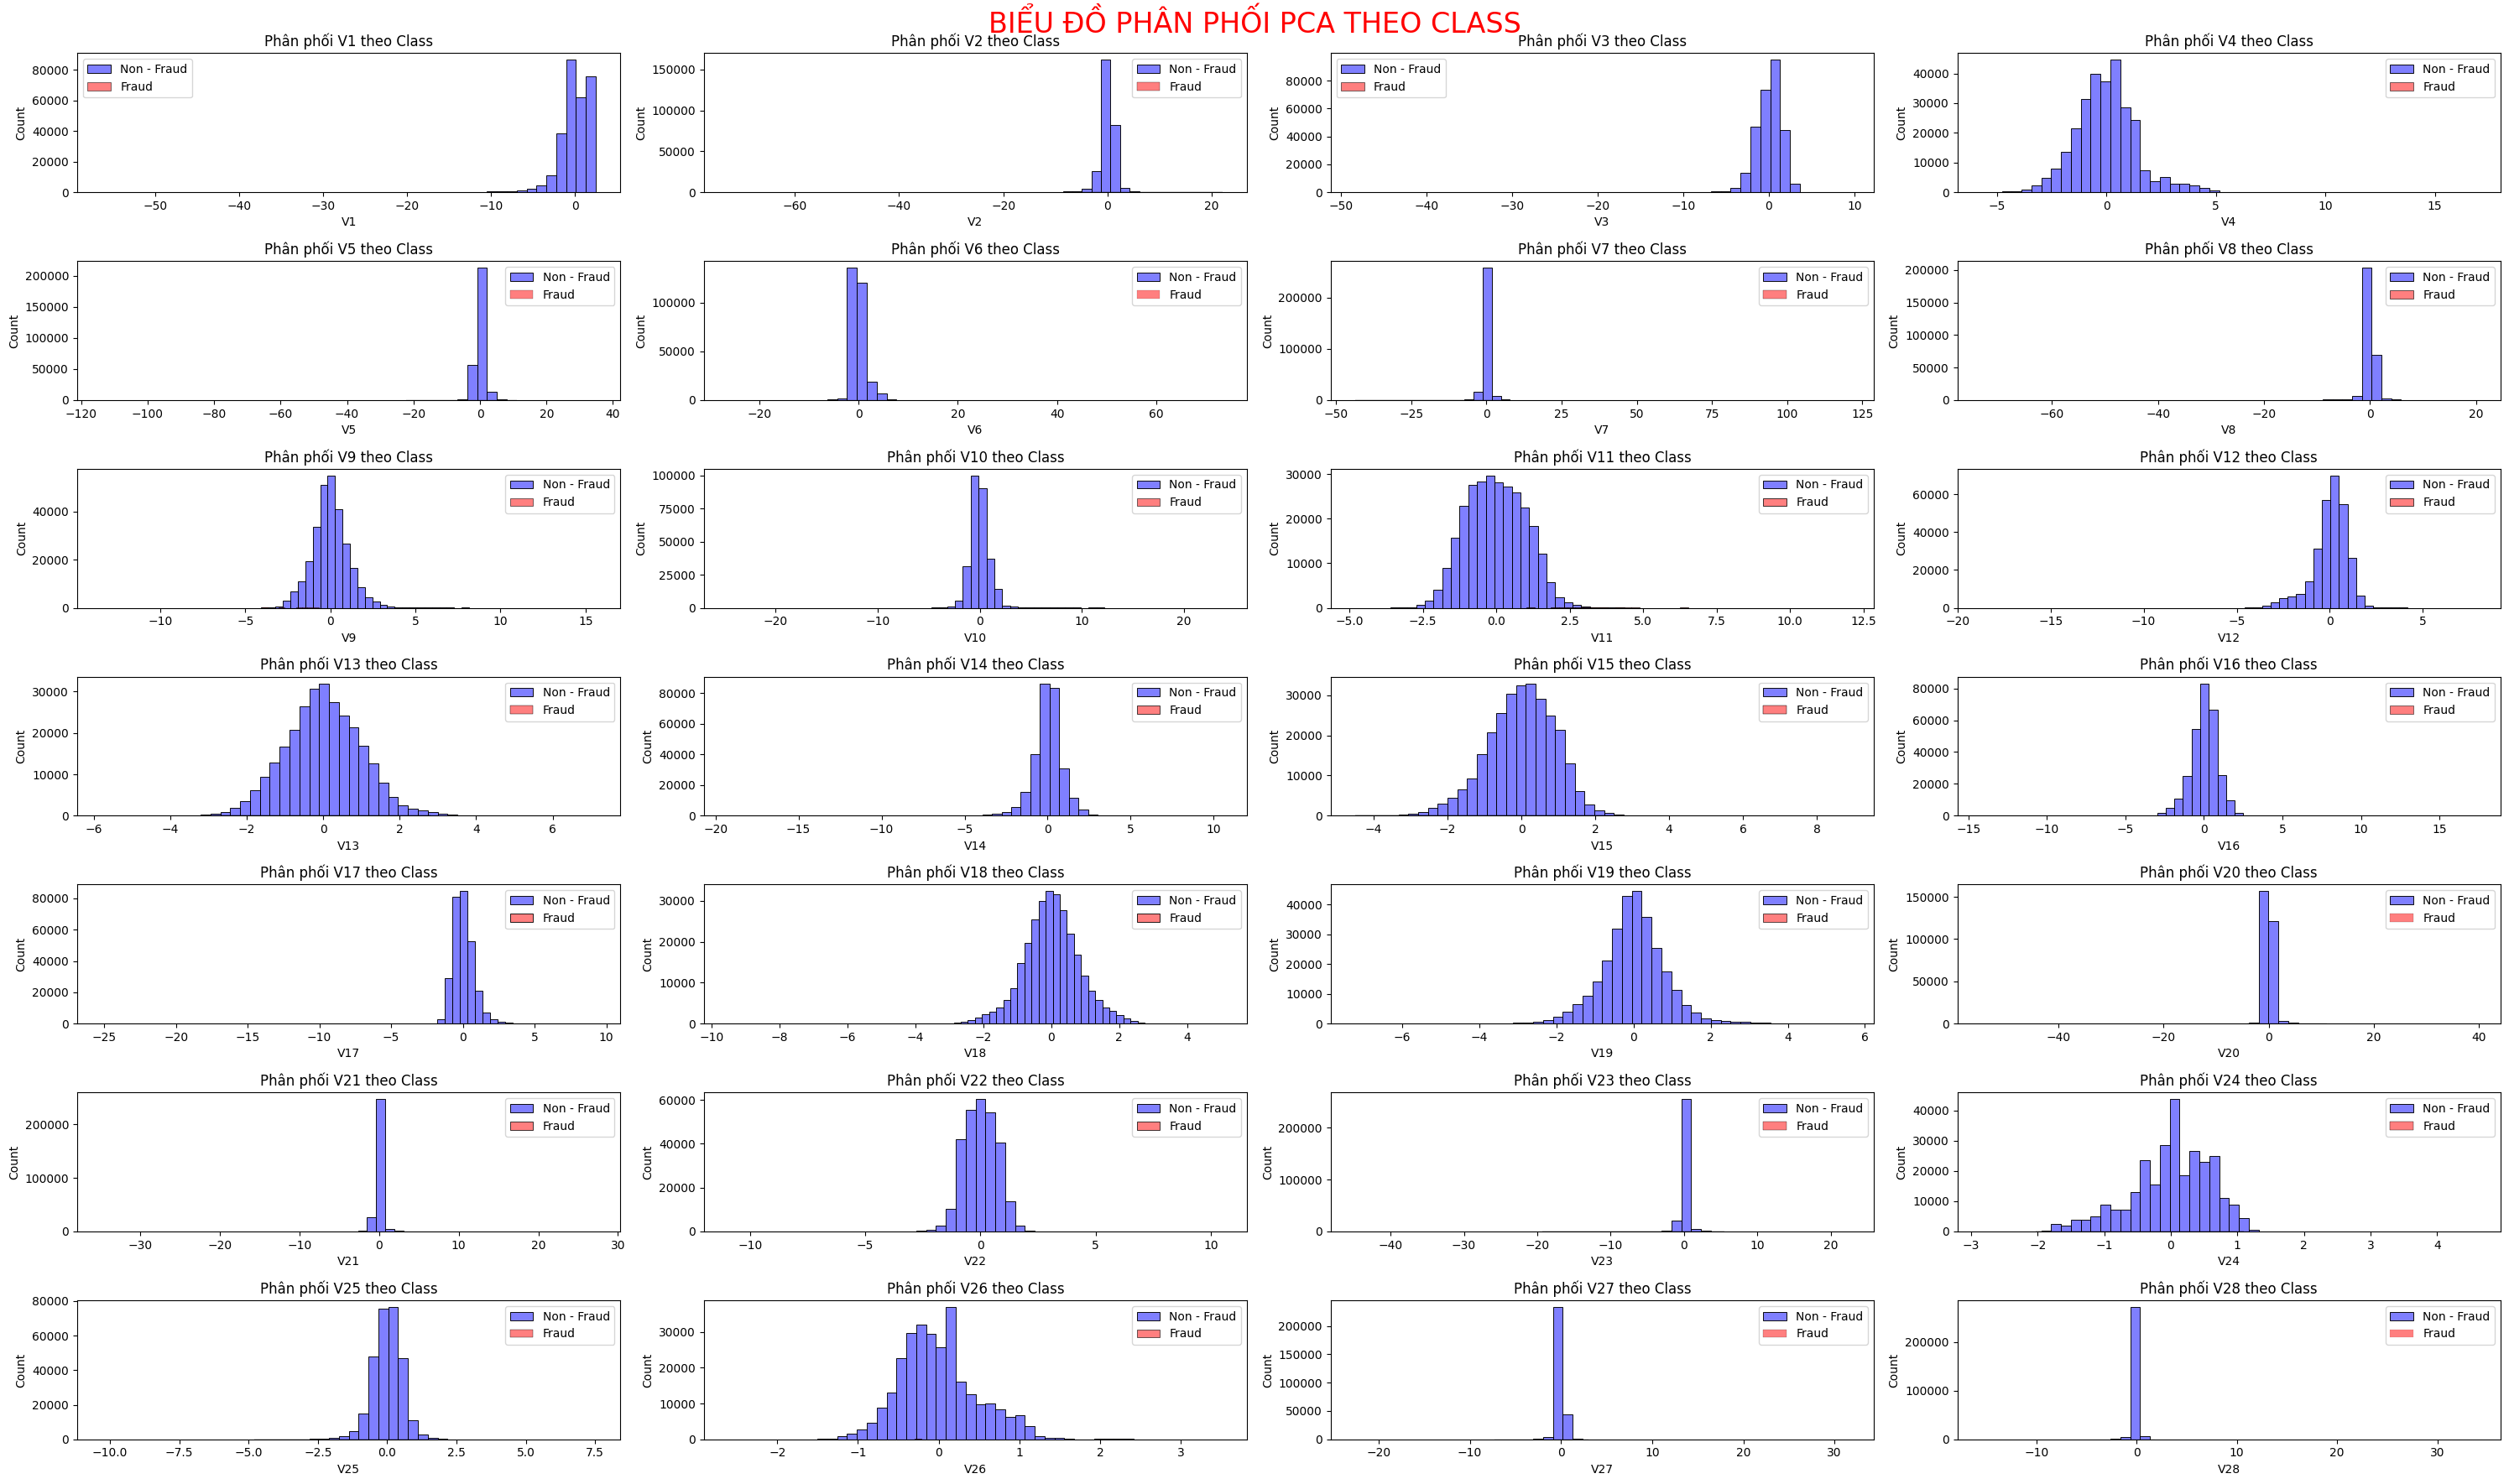

In [66]:
# 2.4. Phân tích và trực quan các đặc trưng PCA
print("PHÂN TÍCH CÁC ĐẶC TRƯNG PCA (V1 - V28)")
print("-" * 50)

fig4 = plt.figure(figsize=(30, 18))
pca_features = [f"V{i}" for i in range(1, 29)]

for i, feature in enumerate(pca_features):
    plt.subplot(7, 4, i + 1)
    sns.histplot(df[df['Class'] == 0][feature], bins=50, color='blue', alpha=0.5, label='Non - Fraud')
    sns.histplot(df[df['Class'] == 1][feature], bins=50, color='red', alpha=0.5, label='Fraud')
    plt.title(f"Phân phối {feature} theo Class")
    plt.xlabel(feature)
    plt.legend()

fig4.suptitle("BIỂU ĐỒ PHÂN PHỐI PCA THEO CLASS", fontsize=24, color='red')
plt.tight_layout()
plt.show()

PHÂN TÍCH TƯƠNG QUAN (CORRELATION)
--------------------------------------------------


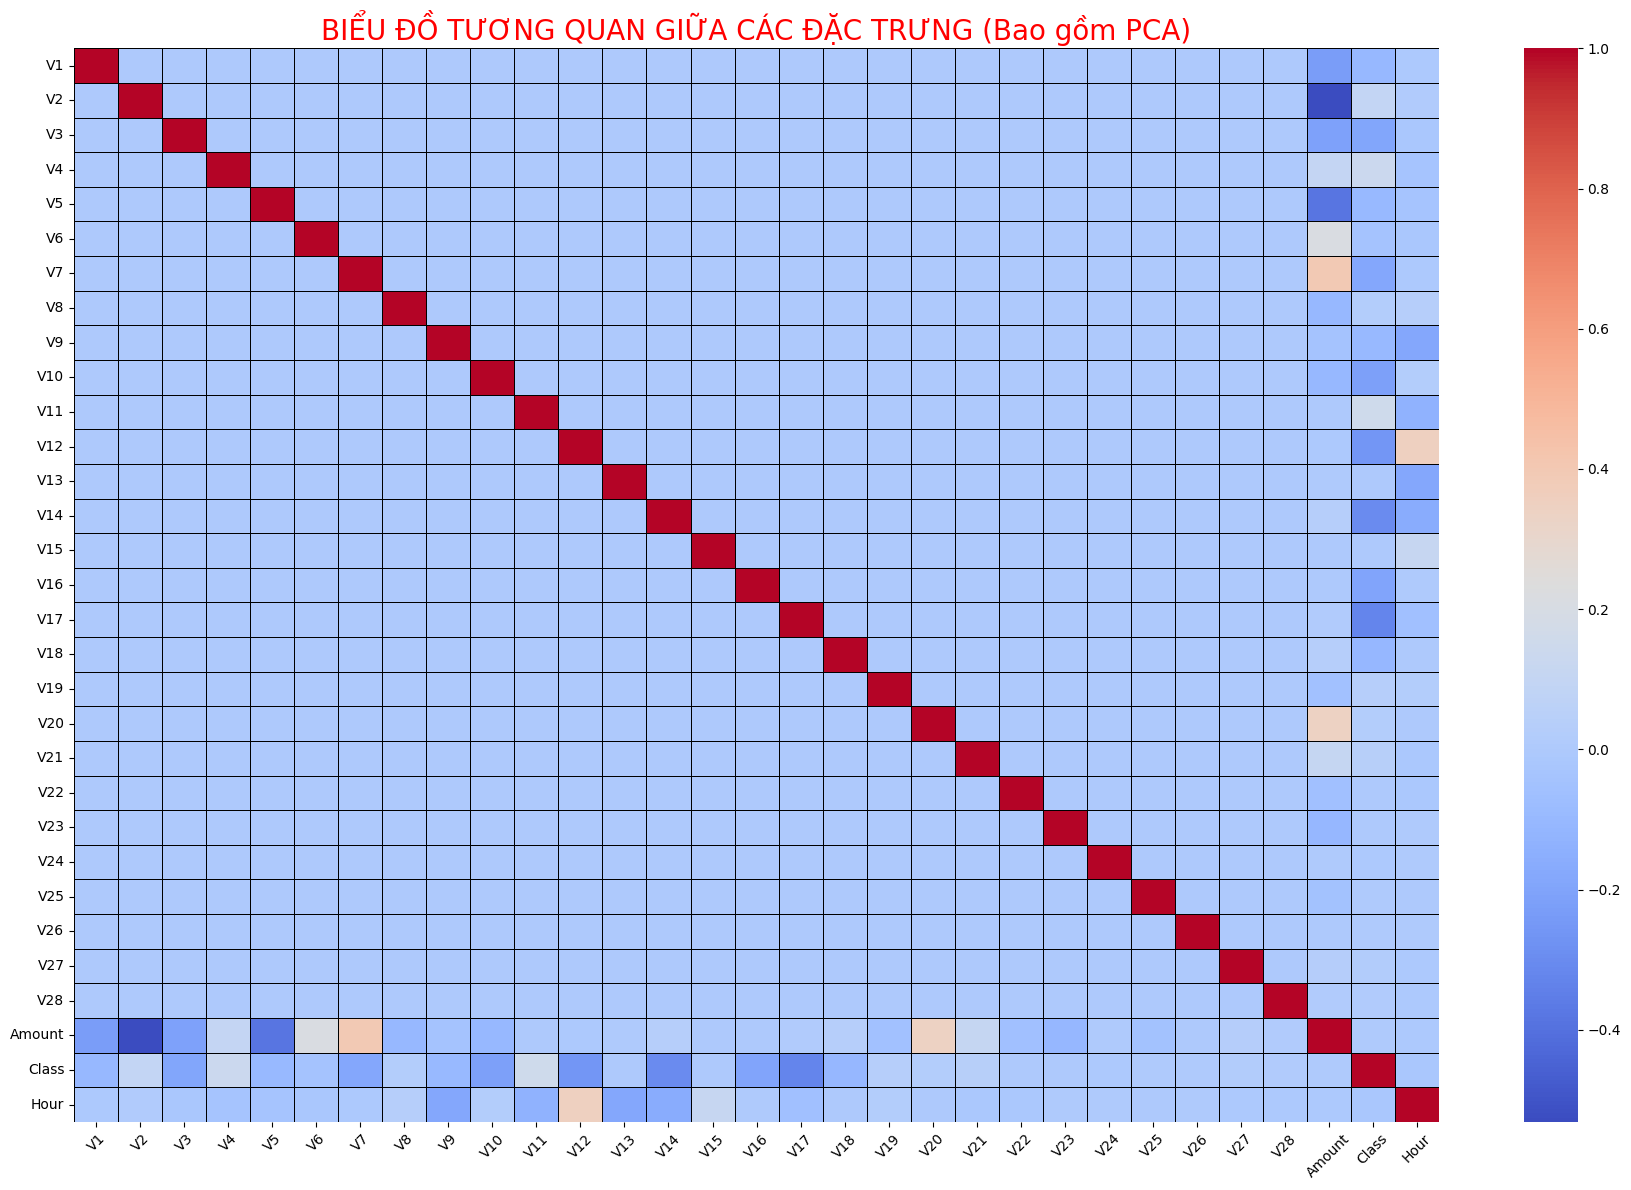

/tmp/ipykernel_152/2734413567.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_cor_target.index, y=df_cor_target.values, palette='viridis')


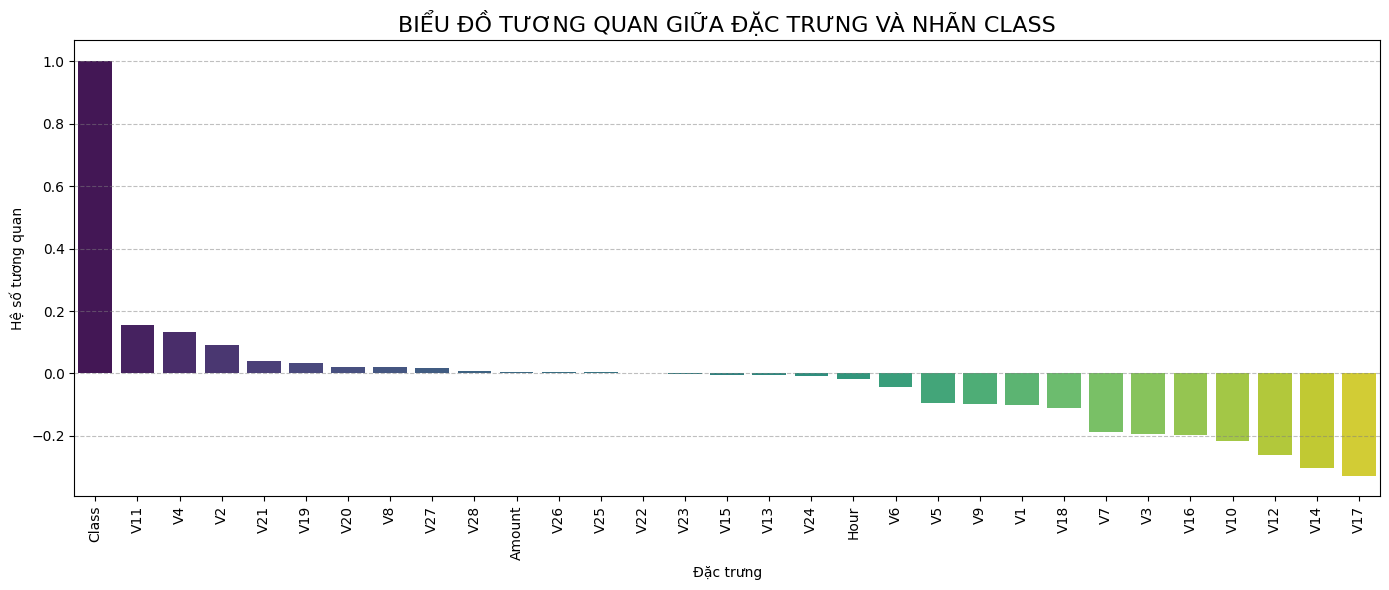

In [67]:
# 2.5. Phân tích và vẽ biểu đồ Tương quan
print("PHÂN TÍCH TƯƠNG QUAN (CORRELATION)")
print("-" * 50)

# Tính ma trận tương quan cho toàn bộ DataFrame (bao gồm các biến PCA)
df_heat = df.corr()

# 2.5.1 Biểu đồ tương quan giữa các đặc trưng (Heatmap)
plt.figure(figsize=(18, 12))
sns.heatmap(data=df_heat, annot=False, cmap='coolwarm', linecolor='black', linewidth=0.5)
plt.title("BIỂU ĐỒ TƯƠNG QUAN GIỮA CÁC ĐẶC TRƯNG (Bao gồm PCA)", fontsize=20, color='red')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2.5.2 Phân tích tương quan với biến mục tiêu (Class)
plt.figure(figsize=(14, 6))
df_cor_target = df_heat["Class"].sort_values(ascending=False)
sns.barplot(x=df_cor_target.index, y=df_cor_target.values, palette='viridis')
plt.title("BIỂU ĐỒ TƯƠNG QUAN GIỮA ĐẶC TRƯNG VÀ NHÃN CLASS", fontsize=16)
plt.xlabel("Đặc trưng")
plt.ylabel("Hệ số tương quan")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', color='gray', alpha=0.5)
plt.tight_layout()
plt.show()

### 💡 Insight :
* **Sự thật từ dữ liệu:**
    * **Đa cộng tuyến (Multicollinearity):** Rất thấp. Các biến V1-V28 hoàn toàn độc lập với nhau (do bản chất của phép biến đổi PCA). Điều này rất tốt cho các mô hình tuyến tính.
    * **Tương quan với biến mục tiêu (Class):** * Tương quan âm mạnh nhất: **V17, V14, V12** (Giá trị càng âm, khả năng gian lận càng cao).
        * Tương quan dương mạnh nhất: **V11, V4**.
* **Hành động (Action):** Kết quả này hoàn toàn khớp với phân phối ở biểu đồ PCA phía trên, khẳng định chất lượng dữ liệu đầu vào đã sẵn sàng cho bước lập mô hình.

- Tương quan âm: V17, V14, V12 và V10 có tương quan âm. Giá trị càng thấp thì khả năng kết quả cuối cùng là giao dịch gian lận càng cao.

- Tương quan dương: V2, V4, V11 và V19 có tương quan dương. Giá trị càng cao thì khả năng kết quả cuối cùng là giao dịch gian lận càng cao.

Do là kết quả của phép biến đổi không gian PCA nên dữ liệu đã mang sẵn tính chất phân phối chuẩn và được ẩn danh hóa. Việc can thiệp tiền xử lý như Scale hay xóa Outlier trên các biến này không những không tăng hiệu năng mà còn có nguy cơ làm rò rỉ hoặc đánh mất các tín hiệu gian lận quan trọng.

=> Giữ nguyên ko xử lý

In [68]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2))
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2))

No Frauds 99.83
Frauds 0.17


In [69]:
max_amount = df['Amount'].max()
print(f"Số tiền giao dịch lớn nhất là: ${max_amount}")
min_amount = df['Amount'].min()
print(f"Số tiền giao dịch nhỏ nhất là: ${min_amount}")

Số tiền giao dịch lớn nhất là: $25691.16
Số tiền giao dịch nhỏ nhất là: $0.0


In [70]:
# Tìm vị trí (index) của giao dịch có số tiền lớn nhất
max_index = df['Amount'].idxmax()

# Lấy ra toàn bộ dữ liệu của dòng đó
max_transaction = df.loc[max_index]
print("========Thông tin về giao dịch lớn======== \n")

# In ra xem thử các cột quan trọng
print("Thời gian (giờ):", max_transaction['Hour'])
print("Số tiền:", max_transaction['Amount'])
print("Nhãn (0 = Hợp lệ, 1 = Gian lận):", max_transaction['Class'])

print("========Thông tin về giao dịch nhỏ======== \n")
# Tìm vị trí (index) của giao dịch có số tiền nhỏ nhất
min_index = df['Amount'].idxmin()

# Lấy ra toàn bộ dữ liệu của dòng đó
min_transaction = df.loc[min_index]

# In ra xem thử các cột quan trọng
print("Thời gian (giờ):", min_transaction['Hour'])
print("Số tiền:", min_transaction['Amount'])
print("Nhãn (0 = Hợp lệ, 1 = Gian lận):", min_transaction['Class'])

========Thông tin về giao dịch lớn======== 

Thời gian (giờ): 22.0
Số tiền: 25691.16
Nhãn (0 = Hợp lệ, 1 = Gian lận): 0.0
========Thông tin về giao dịch nhỏ======== 

Thời gian (giờ): 0.0
Số tiền: 0.0
Nhãn (0 = Hợp lệ, 1 = Gian lận): 0.0


In [71]:
top_5_amounts = df.nlargest(5, 'Amount')

# Chỉ hiển thị 3 cột quan trọng nhất cho dễ nhìn
print("========Top 5 giao dịch lớn======== \n")
display(top_5_amounts[['Hour', 'Amount', 'Class']])

print("========Bottom 5 giao dịch lớn======== \n")
bottom_5_amounts = df.nsmallest(5, 'Amount')

# Chỉ hiển thị 3 cột quan trọng nhất cho dễ nhìn
display(bottom_5_amounts[['Hour', 'Amount', 'Class']])

========Top 5 giao dịch lớn======== 



,Hour,Amount,Class
274771,22.0,25691.16,0
58465,13.0,19656.53,0
151296,2.0,18910.00,0
46841,11.0,12910.93,0
54018,12.0,11898.09,0


========Bottom 5 giao dịch lớn======== 



,Hour,Amount,Class
383,0.0,0.0,0
514,0.0,0.0,0
534,0.0,0.0,0
541,0.0,0.0,1
575,0.0,0.0,0


### Chuẩn hóa dữ liệu xây dựng Baseline

#### Chuẩn hóa Amount và Hour

In [72]:
# Khởi tạo RobustScaler
rob_scaler = RobustScaler()

# Lấy 2 cột để featur engineering
df['Original_Amount'] = df['Amount'].copy()
df['Original_Hour'] = df['Hour'].copy()

# Chuẩn hóa 2 cột Amount và Hour, sau đó tạo cột mới chứa giá trị đã chuẩn hóa
scaled_amount = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
scaled_hour = rob_scaler.fit_transform(df['Hour'].values.reshape(-1, 1))

# 2. Xóa 2 cột Amount và Hour gốc đi để dọn chỗ
df.drop(['Amount', 'Hour'], axis=1, inplace=True)


# 3. Chèn lại 2 cột đó vào vị trí index 0 và 1 với dữ liệu đã chuẩn hóa
df.insert(0, 'Amount', scaled_amount)
df.insert(1, 'Hour', scaled_hour)

print("Đã chuẩn hóa xong Amount và Hour bằng RobustScaler.")

Đã chuẩn hóa xong Amount và Hour bằng RobustScaler.


In [73]:
df

,Amount,Hour,V1,V2,V3,V4,V5,V6,V7,V8,...,V22,V23,V24,V25,V26,V27,V28,Class,Original_Amount,Original_Hour
0,1.783274,-1.666667,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,149.62,0.0
1,-0.269825,-1.666667,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,2.69,0.0
2,4.983721,-1.666667,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,378.66,0.0
3,1.418291,-1.666667,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,123.50,0.0
4,0.670579,-1.666667,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.296653,0.888889,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,0.77,23.0
284803,0.038986,0.888889,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,24.79,23.0
284804,0.641096,0.888889,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,67.88,23.0
284805,-0.167680,0.888889,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,10.00,23.0


#### Xây dựng modell Baseline


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
import pandas as pd

In [75]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    # Lấy các chỉ số đặc biệt quan tâm đến lớp 1 (Fraud) bằng pos_label=1
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob)

    print(f"\n[{model_name}]")
    print("-" * 40)
    print(f"1. Precision (Độ chính xác): {precision:.4f}")
    print(f"2. Recall (Độ phủ/Độ nhạy):   {recall:.4f}")
    print(f"3. F1-Score (Hài hòa):      {f1:.4f}")
    print(f"4. PR-AUC Score:            {pr_auc:.4f}")

    # In thêm Ma trận nhầm lẫn để dễ hình dung số lượng thực tế
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:\n{cm}\n")

    return precision, recall, f1, pr_auc

In [76]:
X = df.drop(['Class','Original_Amount','Original_Hour'], axis=1)
y = df['Class']

# Chia tập Train/Test với tỷ lệ 80/20.
# stratify=y cực kỳ quan trọng để đảm bảo Train và Test đều có 0.17% gian lận
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape[0]} mẫu")
print(f"Kích thước tập Test:  {X_test.shape[0]} mẫu")
print("-" * 80)

Kích thước tập Train: 227845 mẫu
Kích thước tập Test:  56962 mẫu
--------------------------------------------------------------------------------


In [77]:
df

,Amount,Hour,V1,V2,V3,V4,V5,V6,V7,V8,...,V22,V23,V24,V25,V26,V27,V28,Class,Original_Amount,Original_Hour
0,1.783274,-1.666667,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,149.62,0.0
1,-0.269825,-1.666667,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,2.69,0.0
2,4.983721,-1.666667,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,378.66,0.0
3,1.418291,-1.666667,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,123.50,0.0
4,0.670579,-1.666667,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.296653,0.888889,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,0.77,23.0
284803,0.038986,0.888889,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,24.79,23.0
284804,0.641096,0.888889,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,67.88,23.0
284805,-0.167680,0.888889,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,10.00,23.0


In [78]:
X

,Amount,Hour,V1,V2,V3,V4,V5,V6,V7,V8,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,1.783274,-1.666667,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,-0.269825,-1.666667,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,4.983721,-1.666667,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,1.418291,-1.666667,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,0.670579,-1.666667,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.296653,0.888889,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731
284803,0.038986,0.888889,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527
284804,0.641096,0.888889,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561
284805,-0.167680,0.888889,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533


In [79]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
284802,0
284803,0
284804,0
284805,0


#### BASELINE: LogisticRegression

In [80]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

_ = evaluate_model("LOGISTIC REGRESSION (Dữ liệu gốc, chưa cân bằng)", y_test, y_pred_lr, y_prob_lr)

print("=" * 80)


[LOGISTIC REGRESSION (Dữ liệu gốc, chưa cân bằng)]
----------------------------------------
1. Precision (Độ chính xác): 0.8289
2. Recall (Độ phủ/Độ nhạy):   0.6429
3. F1-Score (Hài hòa):      0.7241
4. PR-AUC Score:            0.7380

Confusion Matrix:
[[56851    13]
 [   35    63]]



- 56851: Đúng giao dịch hợp lệ
- 63: Giao dịch gian lận
- 35: giao dịch gian lận nhưng lại dự đoán là hợp lệ (Bỏ lọt tội phạm)
- 13: Giao dịch hợp lệ nhưng nghi ngờ gian lận

### Tiền xử lý dữ liệu

#### Thêm đặc trưng ( feature engineering)

In [81]:
df

,Amount,Hour,V1,V2,V3,V4,V5,V6,V7,V8,...,V22,V23,V24,V25,V26,V27,V28,Class,Original_Amount,Original_Hour
0,1.783274,-1.666667,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,149.62,0.0
1,-0.269825,-1.666667,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,2.69,0.0
2,4.983721,-1.666667,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,378.66,0.0
3,1.418291,-1.666667,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,123.50,0.0
4,0.670579,-1.666667,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.296653,0.888889,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,0.77,23.0
284803,0.038986,0.888889,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,24.79,23.0
284804,0.641096,0.888889,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,67.88,23.0
284805,-0.167680,0.888889,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,10.00,23.0


In [82]:
# Thêm đặc trưng
def add_High_Risk_Hour(df):
    # Điều chỉnh để đánh dấu rủi ro cao vào khung giờ 0-5h sáng VÀ 11h-12h (theo Insight 3)
    df['High_Risk_Hour'] = df['Original_Hour'].apply(lambda x: 1 if (0 <= x <= 5) or (11 <= x <= 12) else 0)
    print("Đã thêm đặc trưng High_Risk_Hour vào Data")
    print("-"*100)
    return df

def add_High_Amount(df):
    df['High_Amount'] = (df['Original_Amount'] > 1000).astype(int)
    print("Đã thêm đặc trưng High_Amount vào Data")
    print("-"*100)
    return df

def add_High_Amount_Risk_Hour(df):

    df['High_Amount_Risk_Hour'] = (df['High_Amount'] & df['High_Risk_Hour']).astype(int)
    print("Đã thêm đặc trưng High_Amount_Risk_Hour vào Data")
    print("-"*100)
    return df
# Hàm trực quan hóa
def analize_binary_feature(df, col, target = 'Class', Viz = False):
    print(f"Phân tích đặc trưng {col}:")
    print("-"*100)
    print(df[col].value_counts())
    dataa = df.groupby(col)[target].mean()
    # Với Is Night: trung bình tỉ lệ giao dịch gian lận ban ngày và ban đêm
    print(dataa)

    if Viz:
        print(f"Trực quan hóa cột {col}:")
        print("-"*100)

        fig1 = plt.figure(figsize = (14, 8))

        # Biểu đồ thứ nhất
        plt.subplot(1,2,1)
        sns.countplot(
            data = df,
            x = col,
            hue = target
          )
        plt.yscale('log')
        plt.title(f'Phân tích Fraud - {col}')
        plt.xlabel(col)
        plt.ylabel('Tần suất xuất hiện (Log Scale)')

        # Biểu đồ thứ hai
        plt.subplot(1,2,2)
        # Phương pháp 2: Chuyển Series thành DataFrame và vẽ bằng seaborn
        dataa_df = dataa.reset_index()  # Chuyển Series thành DataFrame
        dataa_df.columns = [col, target]  # Đặt tên cho các cột

        sns.barplot(
            data = dataa_df,
            x = col,
            y = target,
            hue = col
          )
        plt.title(f'Giá trị trung bình của {target} theo {col}')
        plt.ylabel(f'Giá trị trung bình của {target}')

        fig1.suptitle(f"BIỂU ĐỒ PHÂN TÍCH BIẾN {col}", fontsize = 25, color = 'black')
        plt.tight_layout()

        plt.show()
        print("-"*100)

In [83]:
# Hàm tiền xử lý dữ liệu
def preprocess_data(df_arg): # Renamed the parameter to df_arg to avoid any confusion with a global 'df' in Python's scoping rules.
    print("\n TIỀN XỬ LÝ DỮ LIỆU:")
    print("-"*100)

    #3.1 Thêm đặc trưng phi tuyến
    print("Tiến hành thêm đặc trưng phi tuyến:")
    print("-"*100)

    # Thêm đặc trưng Is_Night
    df_arg = add_High_Risk_Hour(df_arg)
    analize_binary_feature(df_arg, col = 'High_Risk_Hour', Viz = False)

    # Thêm đặc trưng High_Amount
    df_arg = add_High_Amount(df_arg)
    analize_binary_feature(df_arg, col = 'High_Amount', Viz = False)

    # Thêm đặc trưng High_Amount_at_Night
    df_arg = add_High_Amount_Risk_Hour(df_arg)
    analize_binary_feature(df_arg, col = 'High_Amount_Risk_Hour', Viz = False)


    X_processed = df_arg.drop(['Class','Original_Amount','Original_Hour'], axis=1)
    y_target = df_arg['Class']



    #3.3 Chia tập huấn luyện
    print("Tiến hành chia tập huấn luyện!")
    print("-"*100)
    X_train, X_test, y_train, y_test = train_test_split(X_processed, y_target, test_size = 0.2, random_state = 42, stratify = y_target)

    # Kiểm tra lại phân phối nhãn trong tập Train và Test
    print("Tỷ lệ nhãn Fraud trong tập train: ", Counter(y_train)[1]/len(X_train))
    print("Tỷ lệ nhãn Fraud trong tập test: ", Counter(y_test)[1]/len(X_test))

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = preprocess_data(df.copy())


 TIỀN XỬ LÝ DỮ LIỆU:
----------------------------------------------------------------------------------------------------
Tiến hành thêm đặc trưng phi tuyến:
----------------------------------------------------------------------------------------------------
Đã thêm đặc trưng High_Risk_Hour vào Data
----------------------------------------------------------------------------------------------------
Phân tích đặc trưng High_Risk_Hour:
----------------------------------------------------------------------------------------------------
High_Risk_Hour
0    228597
1     56210
Name: count, dtype: int64
High_Risk_Hour
0    0.001304
1    0.003451
Name: Class, dtype: float64
Đã thêm đặc trưng High_Amount vào Data
----------------------------------------------------------------------------------------------------
Phân tích đặc trưng High_Amount:
----------------------------------------------------------------------------------------------------
High_Amount
0    281867
1      2940
Name: count, d

In [84]:
df.drop(['Original_Amount', 'Original_Hour'], axis=1, inplace=True)

In [85]:
X_train

,Amount,Hour,V1,V2,V3,V4,V5,V6,V7,V8,...,V22,V23,V24,V25,V26,V27,V28,High_Risk_Hour,High_Amount,High_Amount_Risk_Hour
265518,-0.205128,0.555556,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,...,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,0,0,0
180305,-0.265633,-0.555556,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,...,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,0,0,0
42664,2.139314,-0.444444,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,...,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,1,0,0
198723,-0.222176,-0.333333,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,...,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,1,0,0
82325,0.895689,0.111111,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,...,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,-0.223713,0.222222,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,...,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,0,0,0
85418,0.209460,0.111111,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,...,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,0,0,0
29062,0.327255,-0.666667,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,...,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,0,0,0
13766,-0.294977,-1.000000,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,...,-0.961351,0.033153,-0.560429,0.278428,0.089546,-0.059835,-0.005887,0,0,0


In [86]:
y_train

,Class
265518,0
180305,0
42664,0
198723,0
82325,0
...,...
233802,0
85418,0
29062,0
13766,0


In [87]:
X


,Amount,Hour,V1,V2,V3,V4,V5,V6,V7,V8,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,1.783274,-1.666667,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,-0.269825,-1.666667,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,4.983721,-1.666667,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,1.418291,-1.666667,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,0.670579,-1.666667,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-0.296653,0.888889,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,...,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731
284803,0.038986,0.888889,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,...,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527
284804,0.641096,0.888889,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,...,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561
284805,-0.167680,0.888889,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,...,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533


#### Xử lý dữ liệu mất cân bằng

In [88]:
# Xử lý mất cân bằng dữ liệu

def handle_imbalanced_data(X_train, y_train):
    print("XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU:")
    print("-"*100)

    # 4.1 In ra phân phối nhãn ban đầu
    print("Phân phối ban đầu: ", Counter(y_train))
    print("-"*100)

    # 4.2 Kỹ thuật Random Under - sampling
    print("Thực hiện kỹ thuật Random Under-sampling: ")
    rus = RandomUnderSampler(
        sampling_strategy = 0.1,
        random_state = 42
      ) # Khởi tạo bộ biến đổi
    X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train) # Áp dụng biến đổi

    print("Phân phối sau Random Under-sampling: ", Counter(y_train_rus))
    print("-"*100)

    # 4.3 Kỹ thuật SMOTE (Synthetic Minority Over-sampling Technique)
    print("Thực hiện kỹ thuật Smote:")
    smote = SMOTE(
        sampling_strategy = 0.1,
        random_state = 42
      ) # Khởi tạo bộ biến đổi
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) # Áp dụng bộ biến đổi

    print("Phân phối sau SMOTE: ", Counter(y_train_smote))
    print("-"*100)

    # 4.4 Kết hợp Under-sampling với SMOTE
    print("Thực hiện kỹ thuật Us-Smote: ")
    rus_smote = RandomUnderSampler(
        sampling_strategy = 0.5,
        random_state = 42
      )
    X_train_rus_smote, y_train_rus_smote = rus_smote.fit_resample(X_train_smote, y_train_smote)
    print("Phân phối sau rus - SMOTE: ", Counter(y_train_rus_smote))
    print("-"*100)

    # 4.5 Return kết quả sau xử lý
    return {
        'original':(X_train, y_train),
        'undersampling': (X_train_rus, y_train_rus),
        'smote': (X_train_smote, y_train_smote),
        'combined': (X_train_rus_smote, y_train_rus_smote)
    }

resampled_data = handle_imbalanced_data(X_train, y_train)


XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU:
----------------------------------------------------------------------------------------------------
Phân phối ban đầu:  Counter({0: 227451, 1: 394})
----------------------------------------------------------------------------------------------------
Thực hiện kỹ thuật Random Under-sampling: 
Phân phối sau Random Under-sampling:  Counter({0: 3940, 1: 394})
----------------------------------------------------------------------------------------------------
Thực hiện kỹ thuật Smote:
Phân phối sau SMOTE:  Counter({0: 227451, 1: 22745})
----------------------------------------------------------------------------------------------------
Thực hiện kỹ thuật Us-Smote: 
Phân phối sau rus - SMOTE:  Counter({0: 45490, 1: 22745})
----------------------------------------------------------------------------------------------------


#### Test thử các phương pháp mất cân bằng dữ liệu  

TRỰC QUAN HÓA DỮ LIỆU SAU KHI CÂN BẰNG
----------------------------------------------------------------------------------------------------


/tmp/ipykernel_152/3770639126.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_152/3770639126.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_df, ax=axes[i], palette='viridis')
/tmp/ipykernel_152/3770639126.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_df, ax=axes[i], palette='viridis')


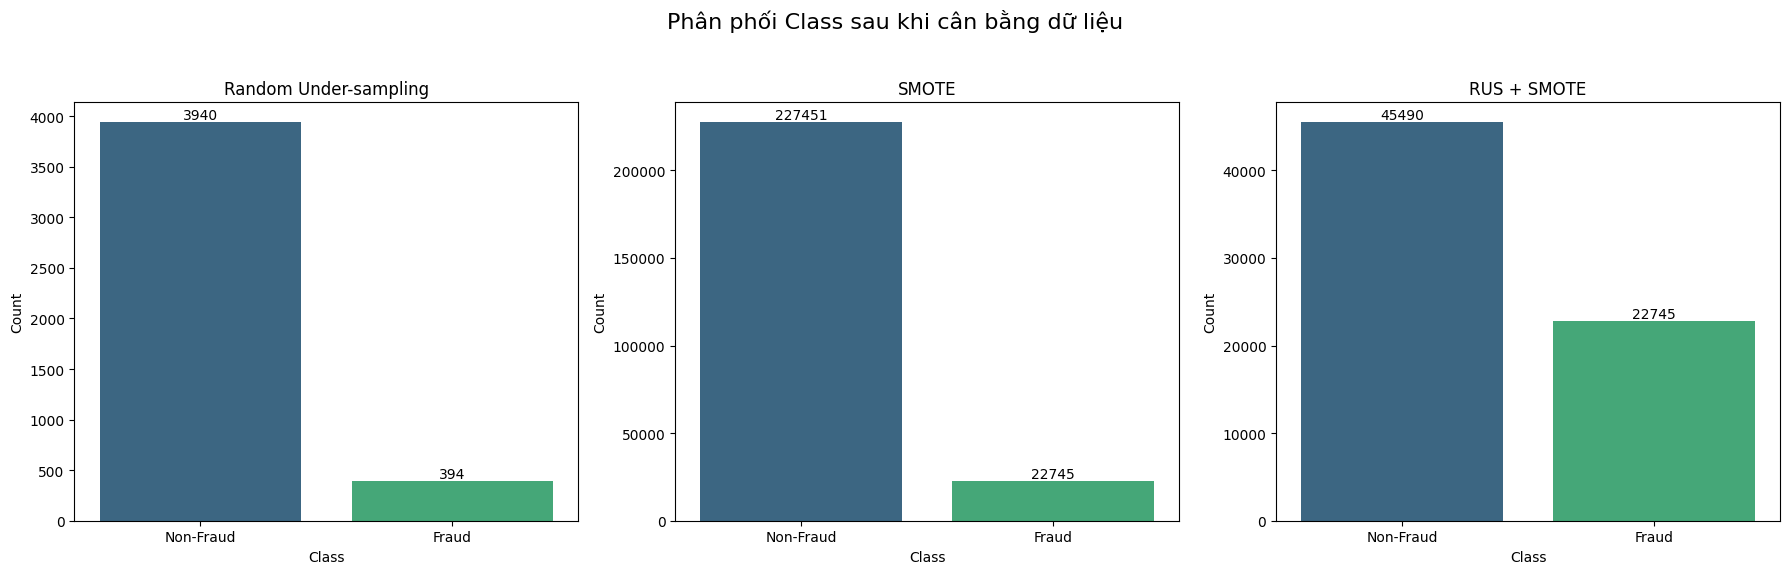

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

print("TRỰC QUAN HÓA DỮ LIỆU SAU KHI CÂN BẰNG")
print("-"*100)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Phân phối Class sau khi cân bằng dữ liệu', fontsize=16)

algorithms = ['undersampling', 'smote', 'combined']
titles = ['Random Under-sampling', 'SMOTE', 'RUS + SMOTE']

for i, algo in enumerate(algorithms):
    y_resampled = resampled_data[algo][1]
    class_counts = Counter(y_resampled)
    class_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])

    sns.barplot(x='Class', y='Count', data=class_df, ax=axes[i], palette='viridis')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])

    # Add count labels on top of the bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Xây dựng mô hình

#### Random Forest

In [90]:
def rf_model():
    rf_model = RandomForestClassifier(
        n_estimators = 50, # 50 cây
        max_depth = 10,  # độ sâu tối đa 10
        min_samples_split = 5,
        random_state = 42,
        oob_score = True,
        n_jobs = -1,                     # Tận dụng toàn bộ CPU
        verbose = 0
      )
    return rf_model

rf_model = rf_model()

#### MLP

##### *`MLP`*(Tensorflow)

---



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9989 - auc: 0.8597 - loss: 0.0113 - val_accuracy: 0.9993 - val_auc: 0.9383 - val_loss: 0.0034
Epoch 2/3
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9994 - auc: 0.9386 - loss: 0.0039 - val_accuracy: 0.9993 - val_auc: 0.9535 - val_loss: 0.0031
Epoch 3/3
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9994 - auc: 0.9480 - loss: 0.0032 - val_accuracy: 0.9994 - val_auc: 0.9486 - val_loss: 0.0031


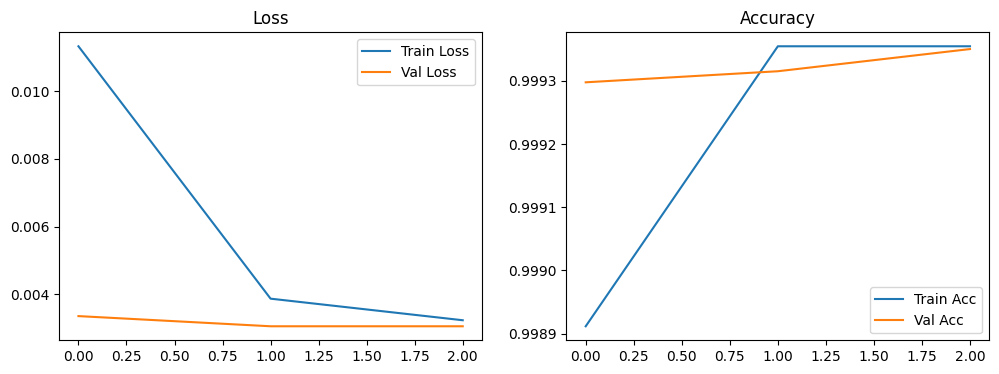

In [91]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.metrics import Precision, Recall, AUC

# Xây dựng model
model = Sequential([
    #Input(shape = (X_train.shape[1],)),
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # nhị phân
])

# Compile
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.AUC(name='auc')]
    # Chỉ số phụ để quan sát trong quá trình huấn luyện (không ảnh hưởng đến gradient)
)

model.summary()

history = model.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
    epochs = 3,
    batch_size = 128,
    verbose = 1
)

# Vẽ loss và accuracy
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
plt.plot(
    history.history['loss'],
    label='Train Loss'
  )
plt.plot(
    history.history['val_loss'],
    label='Val Loss'
  )
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(
    history.history['accuracy'],
    label='Train Acc'
  )
plt.plot(
    history.history['val_accuracy'],
    label='Val Acc'
  )
plt.legend()
plt.title("Accuracy")
plt.show()

#####MLP(Pytorch)

##### Hàm train model với **Pytorch**

In [92]:
def train_model(X_train, X_test, y_test, y_train, model = 'Pytorch', num_epochs = 15,threshold = 0.5, verbose = True, Vis = False):
    # Bước 1: Import thư viện
    import torch # Thư viện chính của Pytorch
    import torch.nn as nn # Module chứa các thành phần xây dựng mạng (lớp, loss, activation)
    import torch.optim as optim # Chứa các thuật toán tối ưu (SGD, Adam...)
    from torch.utils.data import TensorDataset, DataLoader

    # Bước 2: Chuyển dữ liệu từ pandas -> tensor
    X_train_t = torch.tensor(
        X_train.values, # Lấy mảng trong DataFrame X_train
        dtype = torch.float32
    )
    y_train_t = torch.tensor(
        y_train.values,
        dtype = torch.float32
    ).view(-1, 1)

    X_test_t = torch.tensor(
        X_test.values,
        dtype = torch.float32
    )

    y_test_t = torch.tensor(
        y_test.values,
        dtype = torch.float32
    ).view(-1, 1)

    print("Đã chuyển đổi dữ liệu Pandas -> Tensor!")
    print('-'*100)

    # Bước 3: Tạo Dataset và Dataloader
    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(
        train_dataset,
        batch_size = 128,
        shuffle = True
      )

    test_loader = DataLoader(
        test_dataset,
        batch_size = 128,
        shuffle = False
    )

    print('Đã chuyển đổi Tensor Dataset và DataLoader!')
    print('-'*100)

    # Bước 4: Xây dựng kiến trúc mô hình MLP
    class MLP(nn.Module):
        def __init__(self, input_dim):
            super(MLP, self).__init__()
            self.layers = nn.Sequential(
                # Lớp ẩn thứ nhất
                nn.Linear(input_dim, 64),
                nn.ReLU(),
                nn.Dropout(0.3),

                # Lớp ẩn thứ hai
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Dropout(0.3),

                # Lớp ẩn thứ ba
                nn.Linear(32, 16),
                nn.ReLU(),

                # Lớp output
                nn.Linear(16, 1),
                nn.Sigmoid()
            )

        def forward(self, x):
            return self.layers(x)

    print('Đã xây dựng kiến trúc mô hình MLP (Class)!')
    print('-'*100)

    # Bước 5: Khởi tạo model, loss, optimizer
    input_dim = X_train.shape[1]
    model = MLP(input_dim) # Khởi tạo mô hình MLP

    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # model = MLP(input_dim).to(device) # Khởi tạo mô hình MLP

    criterion = nn.BCELoss() # binary cross entropy
    optimizer = optim.Adam( # sử dụng thuật toán tối ưu hóa Adam
        model.parameters(), # Lấy trọng số và bias của từng layer
        lr = 0.001
    )

    # Hàm tính chỉ số phụ
    def calculate_metric_(model, data_loader):
        from sklearn.metrics import precision_recall_curve, auc
        all_preds, all_labels = [], []

        # Tính y_probs, lấy y_true
        with torch.no_grad():
            for X_batch, y_batch in data_loader:
                outputs = model(X_batch) # Lấy xác suất dự đoán
                all_preds.extend(outputs.numpy().flatten()) # y_pred
                all_labels.extend(y_batch.numpy().flatten()) # y_true

        # Tính pr_auc
        precision, recall, _ = precision_recall_curve(all_labels, all_preds)
        pr_auc = auc(recall, precision)

        return pr_auc

    # Bước 6: Huấn luyện mô hình
    num_epochs = num_epochs # Tổng số vòng lặp huấn luyện
    train_losses, val_losses = [], [] # Lưu lại loss
    train_pr_auc_, val_pr_auc_ = [], [] # Lưu lại PR AUC

    print('-'*100)
    print("Tiến hành huấn luyện mô hình:")
    print('- -'*50)
    for epoch in range(num_epochs):
        # Bước 6.1: Training - Huấn luyện
        model.train() # Bật chế độ huấn luyện (dropout hoạt động)
        train_loss, correct, train_total = 0, 0, 0

        # Huấn luyện qua từng batch
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad() # Reset Gradient qua từng Batch
            train_outputs = model(X_batch) # Lan truyền xuôi, tính y_prob
            loss = criterion(train_outputs, y_batch) # Tính Loss
            loss.backward()
            optimizer.step()

            # Tính tổng loss trong từng batch
            train_loss += loss.item() * X_batch.size(0)

            # Lấy y_pred, ngưỡng 0.5
            train_preds = (train_outputs >= threshold).float()
            correct += (train_preds == y_batch).sum().item()

            #.sum() trả về một tensor chứa một số duy nhất, ví dụ: tensor(2).
            #.item() biến nó thành giá trị Python scalar (int/float), để có thể cộng dồn hoặc in ra dễ dàng.

            # Tính tổng số mẫu huấn luyện
            train_total += y_batch.size(0) # tensor.size(dim)

        train_loss = train_loss / train_total
        train_pr_auc = calculate_metric_(model, train_loader)

        # Bước 6.2: Evaluation - Đánh giá
        model.eval()
        y_prob, y_pred = [], []
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                val_outputs = model(X_batch)
                loss = criterion(val_outputs, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_preds = (val_outputs >= threshold).float()

                val_correct += (val_preds == y_batch).sum().item()
                val_total += y_batch.size(0)

                y_prob.extend(val_outputs.numpy().flatten()) # y_pred
                y_pred.extend(val_preds.numpy().flatten())

        val_loss = val_loss / val_total
        val_pr_auc = calculate_metric_(model, test_loader)

        # Lưu lại
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_pr_auc_.append(train_pr_auc)
        val_pr_auc_.append(val_pr_auc)

        if verbose:
            # In kết quả huấn luyện
            print(
                f"Epoch {epoch + 1}/{num_epochs} "
                f"- Train Loss: {train_loss:.4f}, Train PR_AUC: {train_pr_auc:.4f} "
                f"- Val Loss: {val_loss:.4f}, Val PR_AUC: {val_pr_auc:.4f}"
            )

    if Vis:
        # Trực quan hóa quá trình huấn luyện
        plt.figure(figsize = (12, 5))

        # Vẽ biểu đồ bên trái: loss - epoch
        plt.subplot(1, 2, 1)

        epochs = np.arange(1, num_epochs + 1)
        # Tập train
        plt.plot(
            epochs,
            train_losses,
            marker = 'o',
            label = 'Train: loss - epoch',
            color = 'skyblue'
        )

        # Tập test
        plt.plot(
            epochs,
            val_losses,
            marker = 'o',
            label = 'Test: loss - epoch',
            color = 'orange'
        )
        plt.title("Loss")

        plt.xticks(epochs)
        plt.grid(
            linestyle = '--',
            alpha = 0.2,
            color = 'black'
        )
        plt.legend()

        # Biểu đồ Pr_AUC - Epoch
        plt.subplot(1, 2, 2)

        # Tập train
        plt.plot(
            epochs,
            train_pr_auc_,
            marker = 'o',
            color = 'skyblue',
            label = 'Train: Pr - Auc'
        )

        # Tập test
        plt.plot(
            epochs,
            val_pr_auc_,
            marker = 'o',
            color = 'orange',
            label = 'Test: Pr - Auc'
        )

        plt.xticks(epochs)

        plt.title("PR - AUC")
        plt.legend()

        plt.suptitle(
            "Training Visualization - Pytorch",
            fontsize = 25
            )
        plt.grid(
            linestyle = '--',
            alpha = 0.2,
            color = 'black'
        )
        plt.tight_layout()
        plt.show()
        plt.close()
    return y_prob, y_pred


Epoch 1/5 - Train Loss: 0.0233, Train Acc: 0.9948 - Val Loss: 0.0037, Val Acc: 0.9983
Epoch 2/5 - Train Loss: 0.0038, Train Acc: 0.9988 - Val Loss: 0.0033, Val Acc: 0.9993
Epoch 3/5 - Train Loss: 0.0034, Train Acc: 0.9994 - Val Loss: 0.0033, Val Acc: 0.9993
Epoch 4/5 - Train Loss: 0.0031, Train Acc: 0.9994 - Val Loss: 0.0034, Val Acc: 0.9993
Epoch 5/5 - Train Loss: 0.0030, Train Acc: 0.9994 - Val Loss: 0.0031, Val Acc: 0.9993


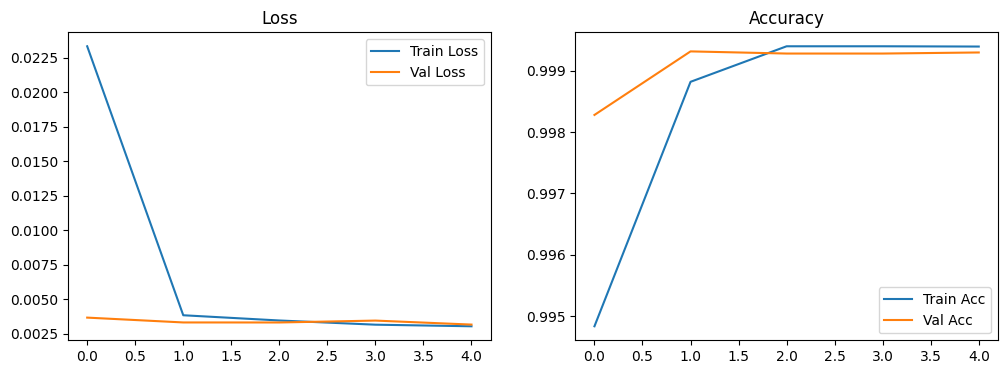

In [93]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Giả sử X_train, y_train, X_test, y_test đã có từ sklearn
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# Tạo Dataset và DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()  # cho nhị phân
        )

    def forward(self, x):
        return self.layers(x)

input_dim = X_train.shape[1]
model = MLP(input_dim)

criterion = nn.BCELoss()               # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    epoch_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = epoch_loss / total
    train_acc = correct / total

    # Evaluation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
            preds = (outputs >= 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Lưu lại
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.show()


### Huấn luyện mô hình và trực quan hóa

#### Trực quan hóa dữ liệu

In [94]:
def eva_and_viz_model(X_test, y_test, y_pred, y_prob, name_pp, show = False):
    print("Tiến hành đánh giá mô hình: ")
    print('-'*200)

    acr = accuracy_score(y_test, y_pred)
    print('Độ chính xác mô hình là: ', acr)
    print("-"*200)

    # Tính Ma trận nhầm lẫn
    c_matrix = confusion_matrix(y_test, y_pred)
    print('Đã tính Ma trận nhầm lẫn! ')
    print('-'*200)

    # Tính Classification_report
    cf_report = classification_report(y_test, y_pred, output_dict = True)
    df_report = pd.DataFrame(cf_report).transpose()
    print('Đã tính Classification Report! ')
    print('-'*200)

    # Extract precision, recall, and f1-score for class 1 (Fraud)
    precision_class_1 = df_report.loc['1', 'precision']
    recall_class_1 = df_report.loc['1', 'recall']
    f1_score_class_1 = df_report.loc['1', 'f1-score']

    # Tính ROC - AUC:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('Đã tính ROC-AUC!')
    print('-'*200)

    # Tính PR - AUC
    precison, recall, _ = precision_recall_curve(y_test, y_prob) # output: precision, recall, thresholds
    pr_auc = auc(recall, precison)
    print('Đã tính PR-AUC!')
    print('-'*200)

    # Trực quan hóa
    if show:
        fig, axs = plt.subplots(
            nrows = 2,
            ncols = 2,
            sharex = False,
            sharey = False,
            squeeze = False,
            figsize = (12,6)
        )

        #Trực quan hóa Confusion Matrix
        sns.heatmap(
            c_matrix,
            annot = True,
            cmap = 'coolwarm',
            linecolor = 'black',
            linewidth = 0.5,
            ax = axs[0,0]
          )
        axs[0,0].set_title("Ma trận nhầm lẫn", fontsize = 16, color = 'red')
        axs[0,0].set_xlabel('Dự đoán')
        axs[0,0].set_ylabel('Thực tế')

        # Trực quan hóa Classification Report
        sns.heatmap(
            df_report,
            annot = True,
            cmap = 'coolwarm',
            linecolor = 'black',
            linewidth = 0.5,
            ax = axs[0,1]
          )
        axs[0,1].set_title("Classification Report", fontsize = 16, color = 'red')
        axs[0,1].set_xlabel('Dự đoán')
        axs[0,1].set_ylabel('Thực tế')

        # Trực quan hóa ROC - AUC
        axs[1,0].plot(
            fpr,
            tpr,
            label = "ROC Curve",
            color = 'green',
            linewidth = 2
            )

        axs[1,0].set_title("ROC CURVE", fontsize = 16, color = 'red')
        axs[1,0].set_xlabel('FPR')
        axs[1,0].set_ylabel('TPR')
        axs[1,0].grid()
        axs[1,0].legend(loc = 'lower right')

        # Trực quan hóa PR - AUC
        axs[1,1].plot(
            precison,
            recall,
            label = 'PR Curve',
            color = 'blue',
            linewidth = 2
            )

        axs[1,1].set_title("PR CURVE", fontsize = 16, color = 'red')
        axs[1,1].set_xlabel('Precison')
        axs[1,1].set_ylabel('Recall')
        axs[1,1].grid()
        axs[1,1].legend(loc = 'lower left')


        fig.suptitle(f"TRỰC QUAN HÓA - {name_pp.upper()}", fontsize = 20, color = 'red')

        plt.tight_layout()
        plt.show()

    return {
        'solu' : name_pp,
        'roc_auc' : roc_auc,
        'pr_auc' : pr_auc,
        'precision_class_1': precision_class_1,
        'recall_class_1': recall_class_1,
        'f1_score_class_1': f1_score_class_1
    }


#### Huấn luyện mô hình Logistic Regresion

HUẤN LUYỆN LOGISTIC REGRESSION VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: ORIGINAL
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9991573329588147
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification R

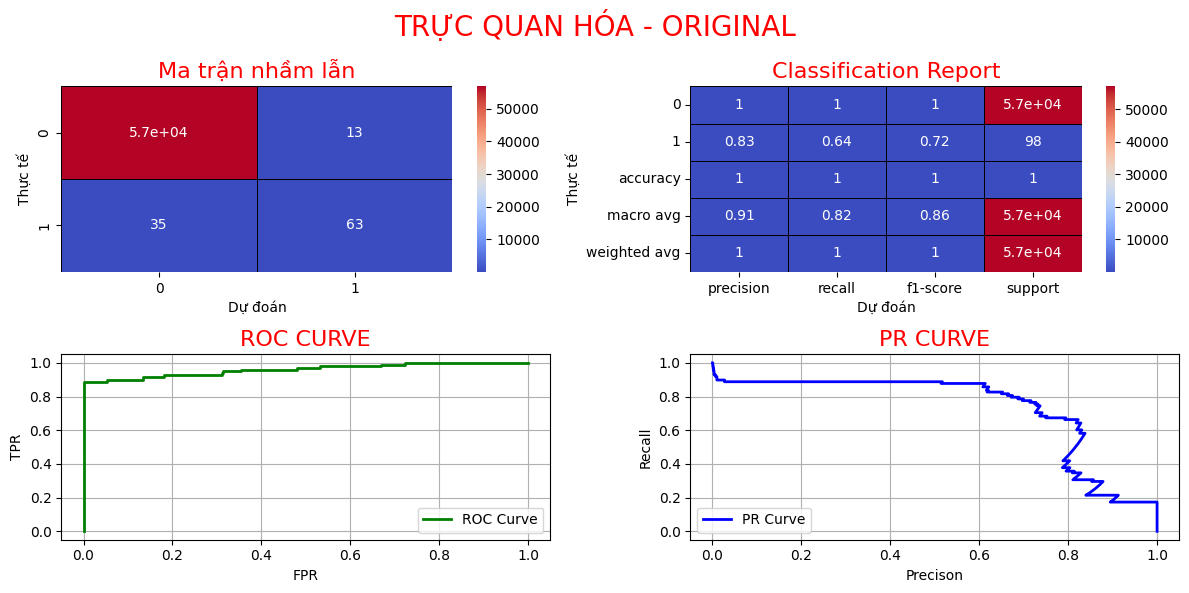


HUẤN LUYỆN LOGISTIC REGRESSION VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: UNDERSAMPLING
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9969804431024192
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classifica

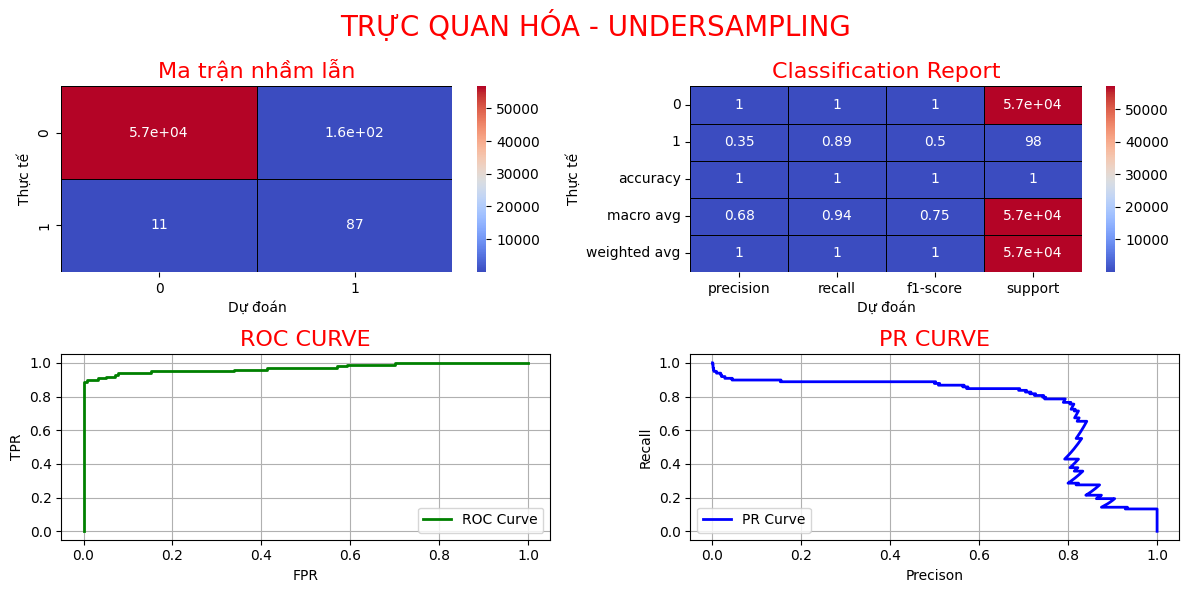


HUẤN LUYỆN LOGISTIC REGRESSION VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: SMOTE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9971208876092834
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Rep

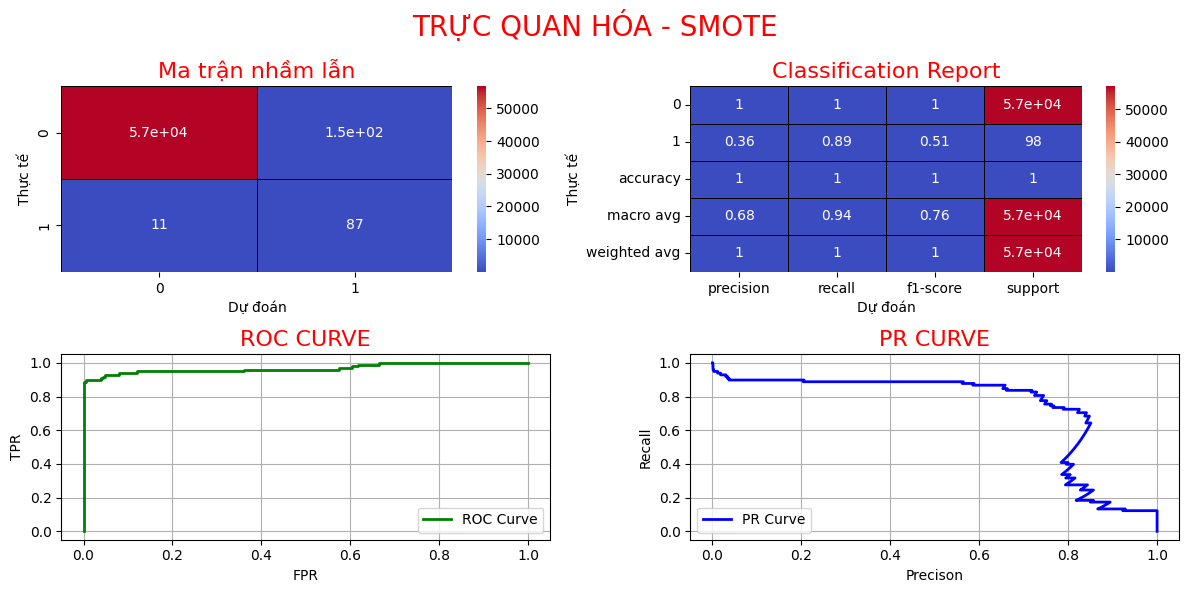


HUẤN LUYỆN LOGISTIC REGRESSION VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: COMBINED
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9864295495242442
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification 

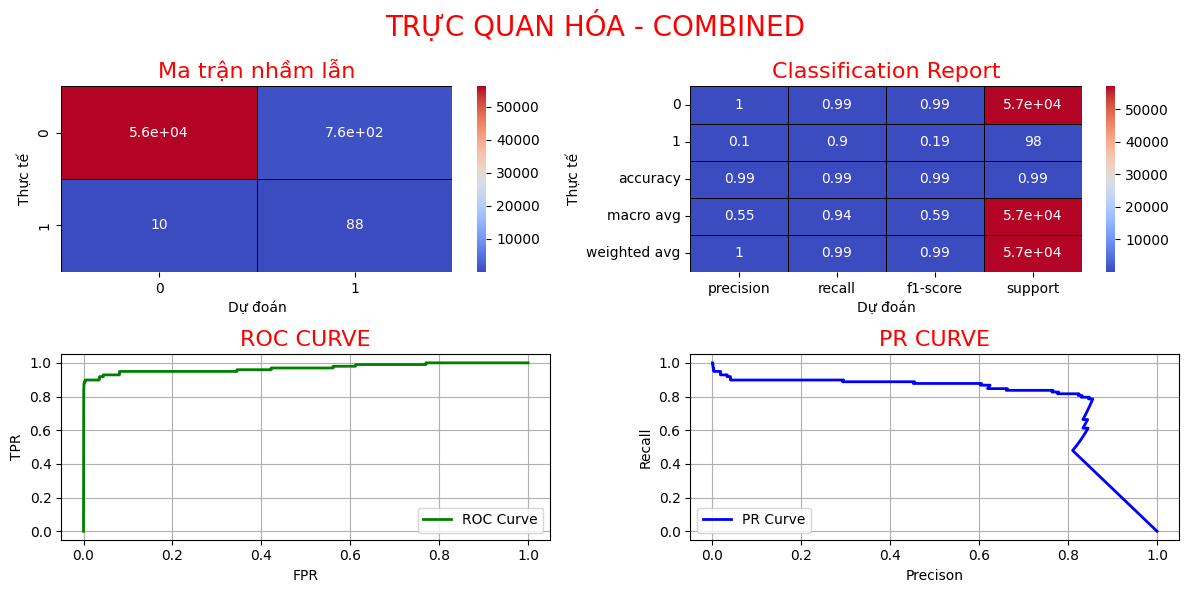

In [95]:
# Huấn luyện mô hình và đánh giá
def train_and_evaluate_lr_model(resampled_data, X_test, y_test):
    resampling_methods = ['original', 'undersampling', 'smote', 'combined']
    results = []

    for method in resampling_methods:
        print("HUẤN LUYỆN LOGISTIC REGRESSION VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU:", method.upper())
        print("-"*200)

        X_train_resampled, y_train_resampled = resampled_data[method]

        lr_model = LogisticRegression(max_iter=1000, random_state=42)
        lr_model.fit(X_train_resampled, y_train_resampled)

        y_pred = lr_model.predict(X_test)
        y_prob = lr_model.predict_proba(X_test)[:, 1]

        result = eva_and_viz_model(X_test, y_test, y_pred, y_prob, method, show=True) # Changed show=False to show=True
        results.append(result)
        print('='*200)
        print()
    return results

results_lr = train_and_evaluate_lr_model(resampled_data, X_test, y_test)

#### Huấn luyện mô hình Random Forest

HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: ORIGINAL
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9995962220427653
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
------------

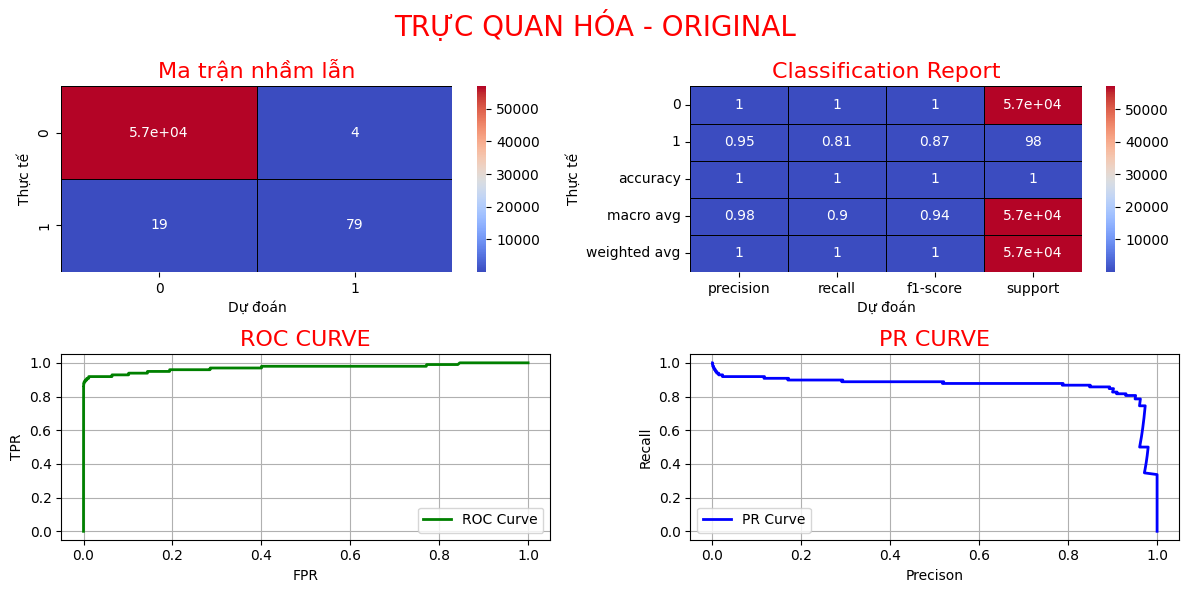


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: UNDERSAMPLING
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9984902215512096
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
------

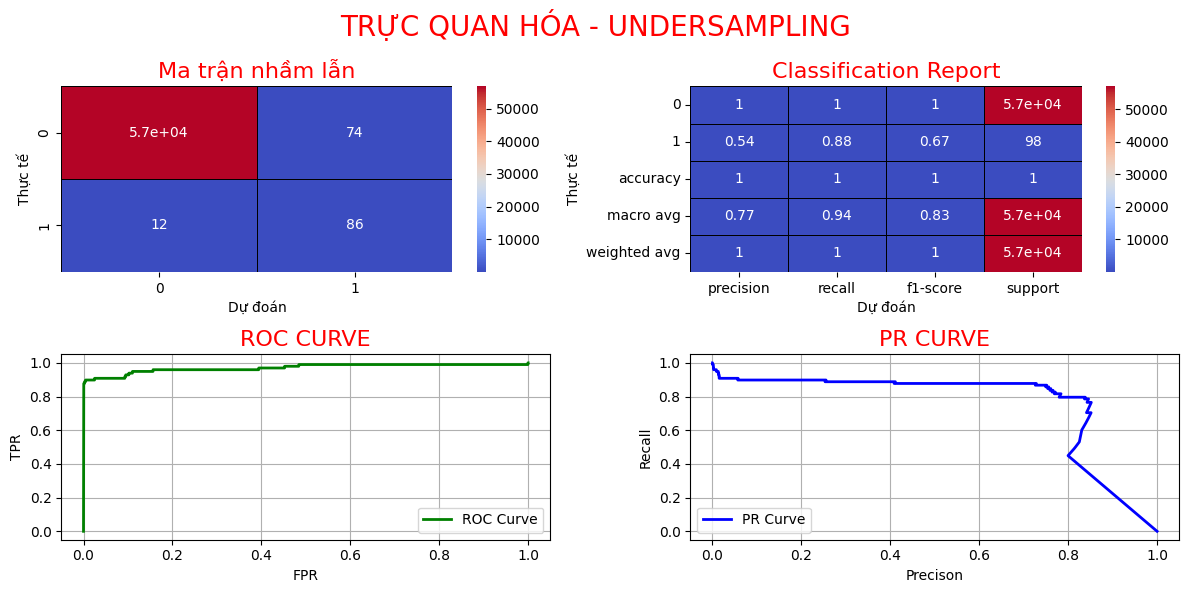


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: SMOTE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9992451107756047
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------

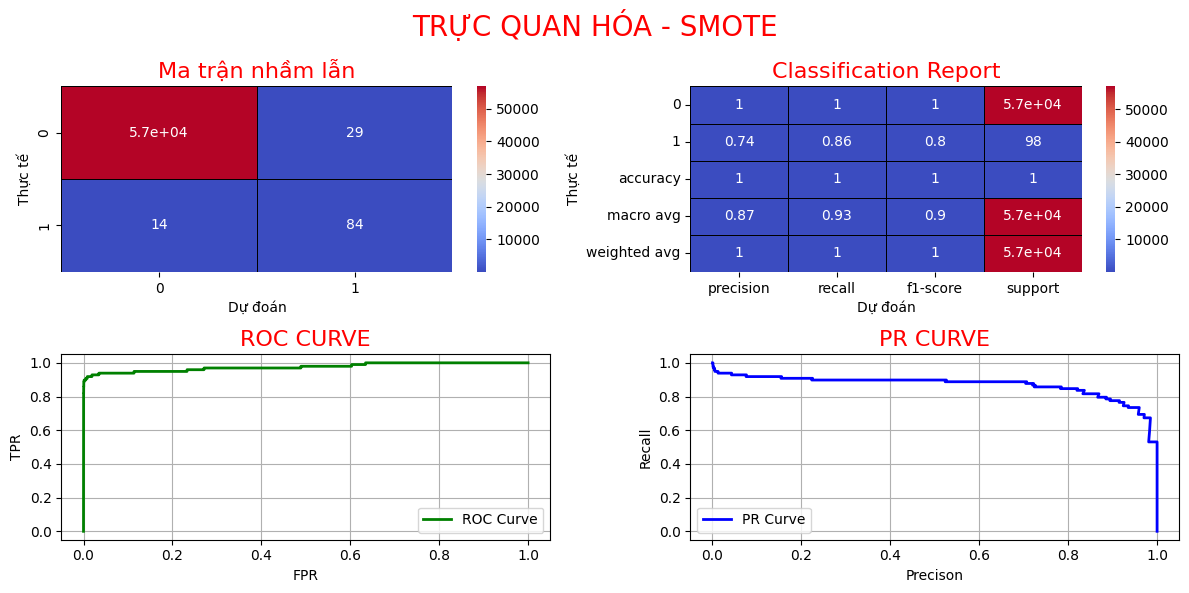


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: COMBINED
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9984902215512096
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
-----------

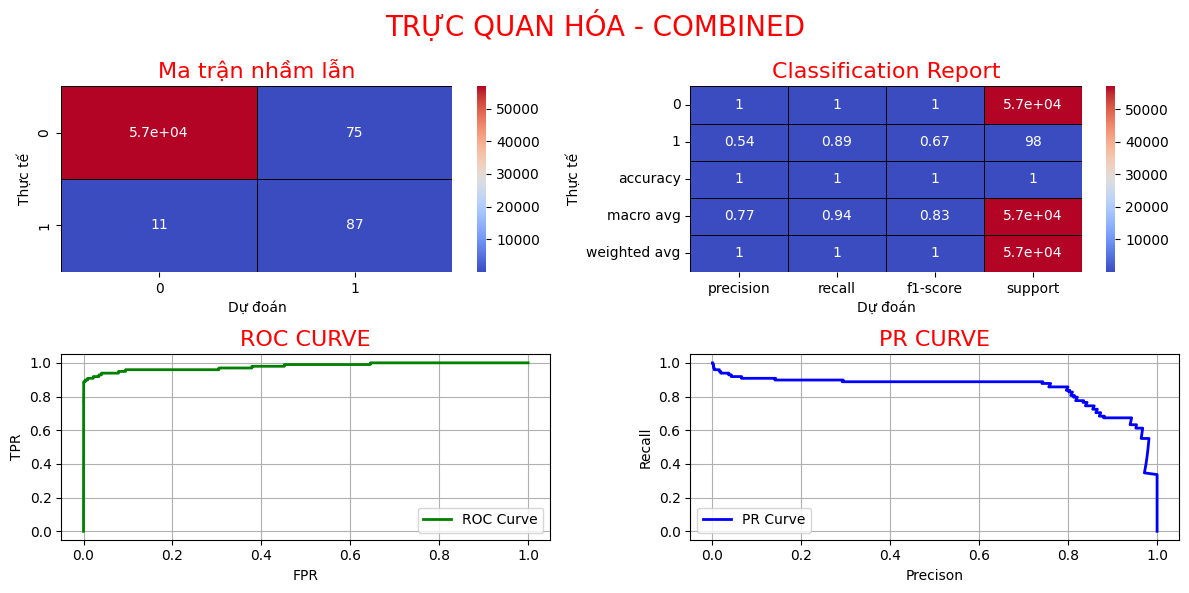

In [96]:
# Thực hành Huấn luyện và đánh giá mô hình
def train_and_evaluate_model(model, resampled_data, X_test, y_test):
    # Danh sách các phương pháp xử lý mất cân bằng
    resampling_methods = ['original', 'undersampling', 'smote', 'combined']

    # Lưu trữ kết quả
    results = []

    # Huấn luyện và đánh giá mô hình
    for method in resampling_methods:
        print("HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU:", method.upper())
        print("-"*200)

        X_train_resampled, y_train_resampled = resampled_data[method]

        # Huấn luyện mô hình
        model.fit(X_train_resampled, y_train_resampled)

        # Dự đoán
        y_pred = model.predict(X_test)

        # Tính Predict_Proba
        y_prob = model.predict_proba(X_test)[:, 1]

        # Đánh giá mô hình:
        result = eva_and_viz_model(X_test, y_test, y_pred, y_prob, method, show = True)
        results.append(result)
        print('='*200)
        print()

    return results

results_rf = train_and_evaluate_model(rf_model, resampled_data, X_test, y_test)

1. Mô hình Random Forest tự nó đã hoạt động khá hiệu quả trên dữ liệu gốc (chưa cân bằng), với Precision rất cao và Recall tốt. Điều này cho thấy Random Forest ít bị ảnh hưởng bởi sự mất cân bằng dữ liệu hơn Logistic Regression và có khả năng học tốt các đặc trưng của cả hai lớp mà không cần cân bằng dữ liệu quá mức.
2. Các kỹ thuật cân bằng dữ liệu (Under-sampling, SMOTE, Combined) mặc dù giúp tăng Recall lên một chút (từ 0.8776 lên khoảng 0.88-0.89), nhưng lại làm giảm đáng kể Precision và tăng số lượng False Positive.
Trong bài toán phát hiện gian lận, việc có Recall cao.
3. Rất quan trọng (không bỏ sót tội phạm), nhưng Precision cũng cần ở mức chấp nhận được để tránh gây phiền toái và chi phí không cần thiết từ các cảnh báo giả.

Mô hình Random Forest trên dữ liệu gốc (chưa cân bằng) có vẻ là lựa chọn tốt nhất hiện tại. Nó cung cấp một sự cân bằng hợp lý giữa việc phát hiện gian lận (Recall 0.8776) và việc không cảnh báo sai các giao dịch hợp lệ (Precision 0.9634). Các kỹ thuật cân bằng dữ liệu trong trường hợp này lại gây ra nhiều False Positive hơn, làm giảm hiệu quả tổng thể của hệ thống

In [97]:
import numpy as np

def select_best_method_rf(results):
    print("CHỌN PHƯƠNG PHÁP XỬ LÝ TỐT NHẤT CHO RANDOM FOREST")
    print("-"*100)

    best_pr_auc_rf = -np.inf
    best_method_rf = None
    for method in results:
        print(f"PR AUC - {method['solu']} : {method['pr_auc']:.4f}")
        print('-'*100)
        if method['pr_auc'] > best_pr_auc_rf:
            best_method_rf = method
            best_pr_auc_rf = method['pr_auc']

    print(f"Phương pháp xử lý mất cân bằng tốt nhất cho Random Forest là: {best_method_rf['solu'].upper()}")
    print(f"Với PR_AUC = {best_pr_auc_rf:.4f}")
    print(f"Và ROC_AUC = {best_method_rf['roc_auc']:.4f}")
    print("-"*100)
    return best_method_rf

best_method_rf = select_best_method_rf(results_rf)


CHỌN PHƯƠNG PHÁP XỬ LÝ TỐT NHẤT CHO RANDOM FOREST
----------------------------------------------------------------------------------------------------
PR AUC - original : 0.8669
----------------------------------------------------------------------------------------------------
PR AUC - undersampling : 0.7636
----------------------------------------------------------------------------------------------------
PR AUC - smote : 0.8699
----------------------------------------------------------------------------------------------------
PR AUC - combined : 0.8464
----------------------------------------------------------------------------------------------------
Phương pháp xử lý mất cân bằng tốt nhất cho Random Forest là: SMOTE
Với PR_AUC = 0.8699
Và ROC_AUC = 0.9753
----------------------------------------------------------------------------------------------------


#### Huấn luyện mô hình MLP

HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: ORIGINAL
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0167, Tra

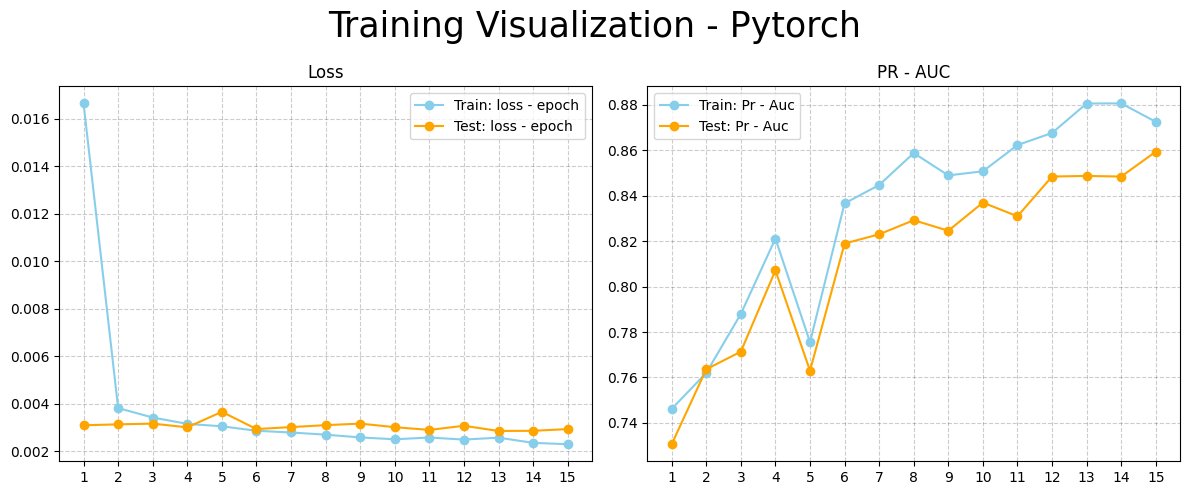

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.999420666409185
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
--------------

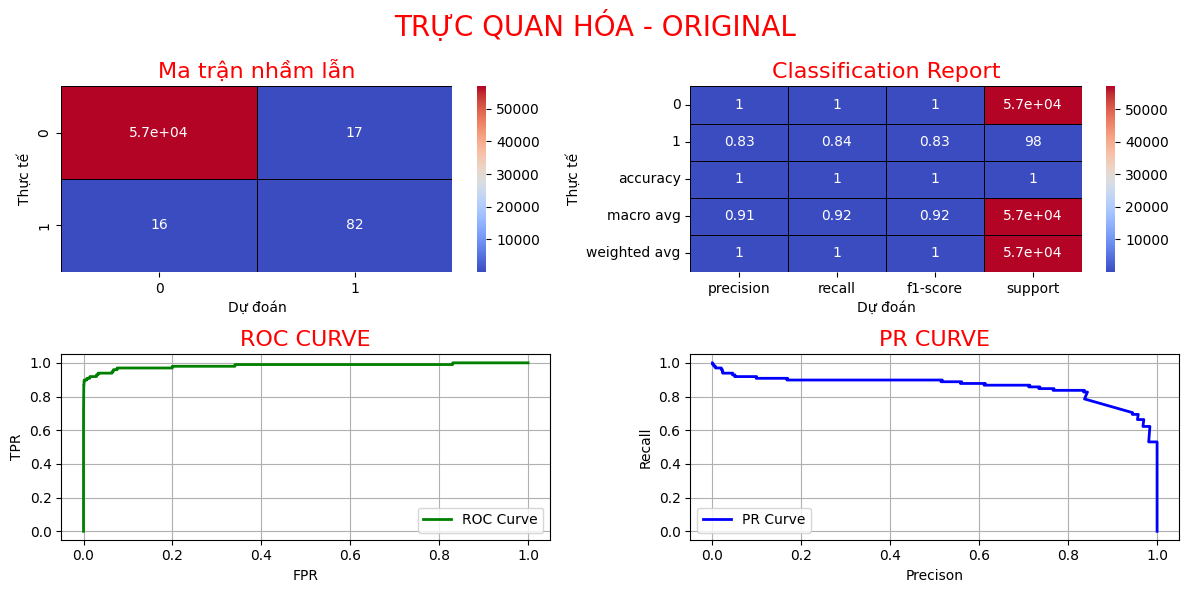


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: UNDERSAMPLING
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.519

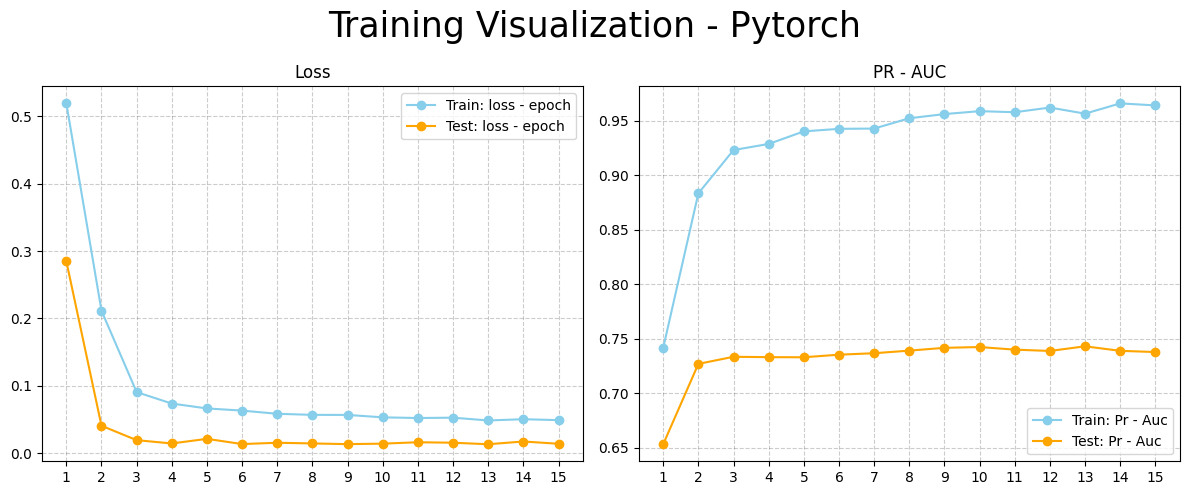

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9974193321863699
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
-------------

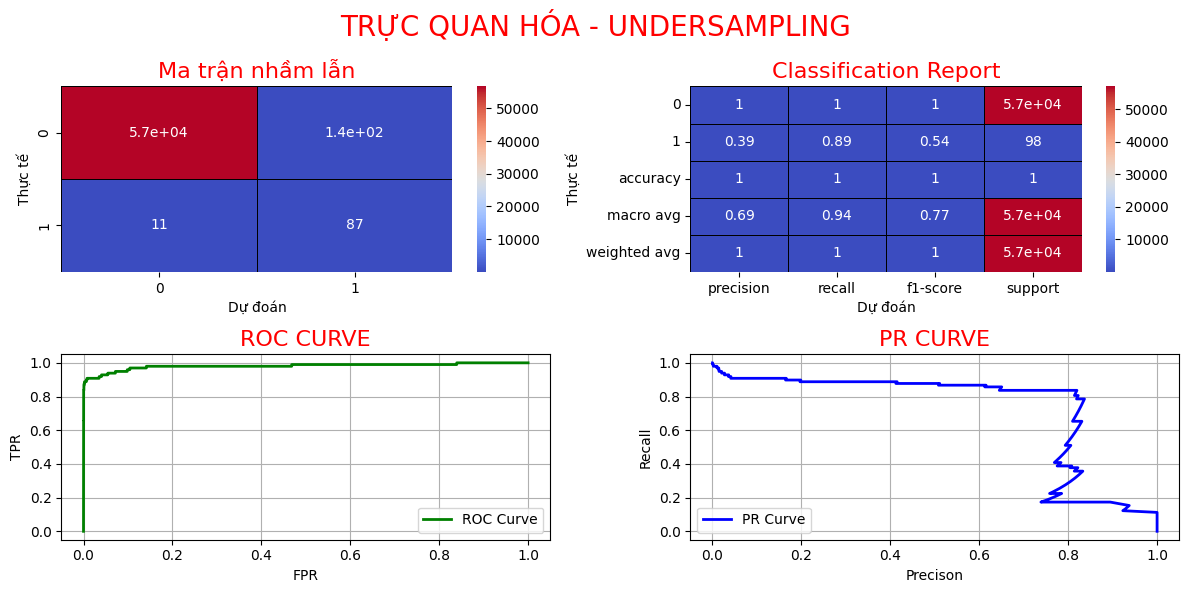


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: SMOTE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.0542, Train

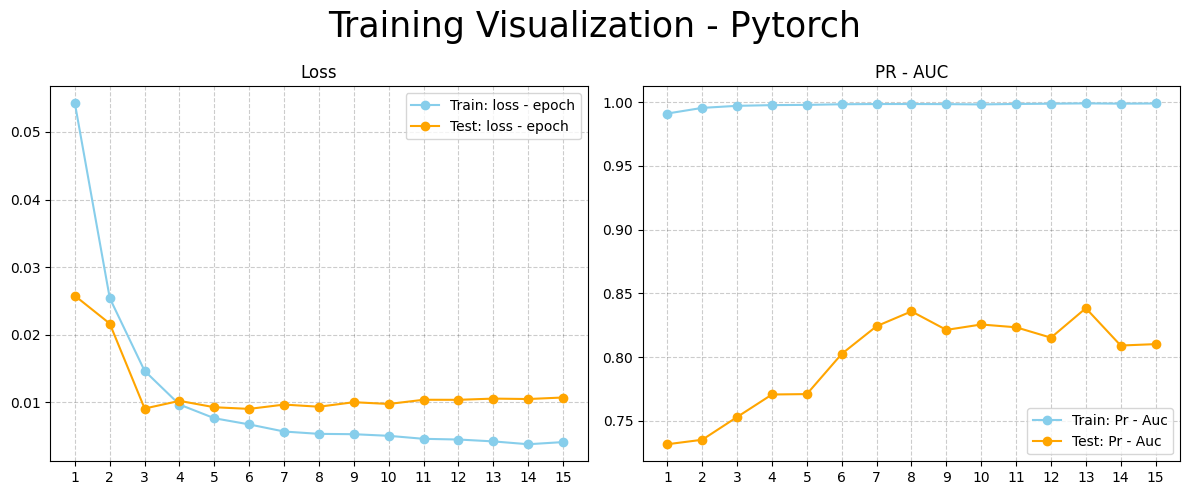

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.9988413328183702
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
-------------

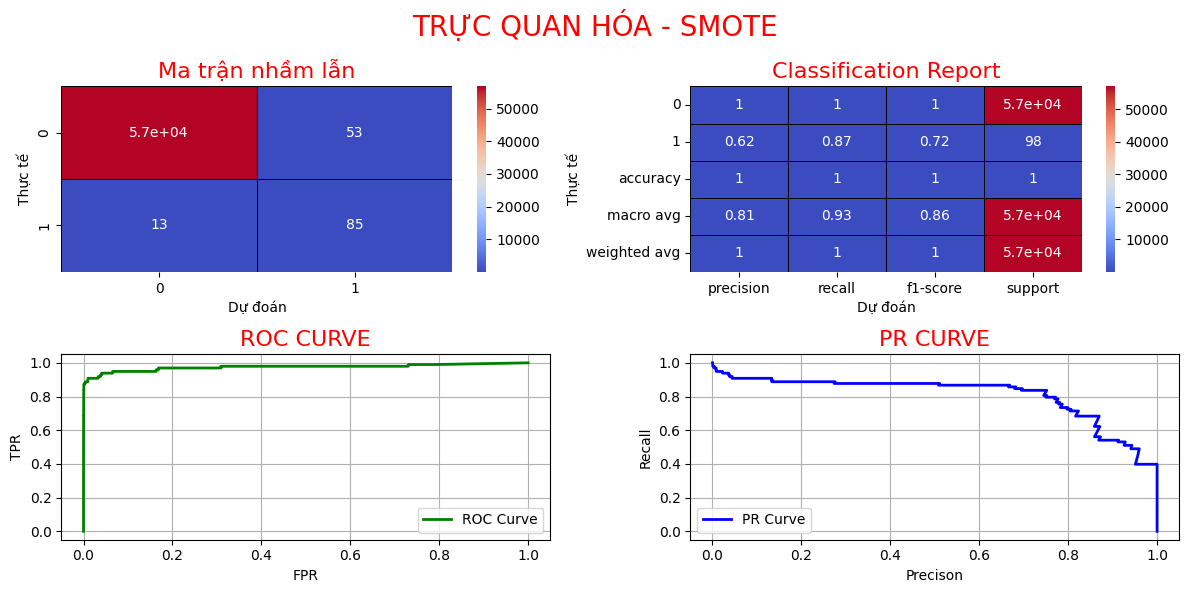


HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU: COMBINED
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã chuyển đổi dữ liệu Pandas -> Tensor!
----------------------------------------------------------------------------------------------------
Đã chuyển đổi Tensor Dataset và DataLoader!
----------------------------------------------------------------------------------------------------
Đã xây dựng kiến trúc mô hình MLP (Class)!
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Tiến hành huấn luyện mô hình:
- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -
Epoch 1/15 - Train Loss: 0.1391, Tr

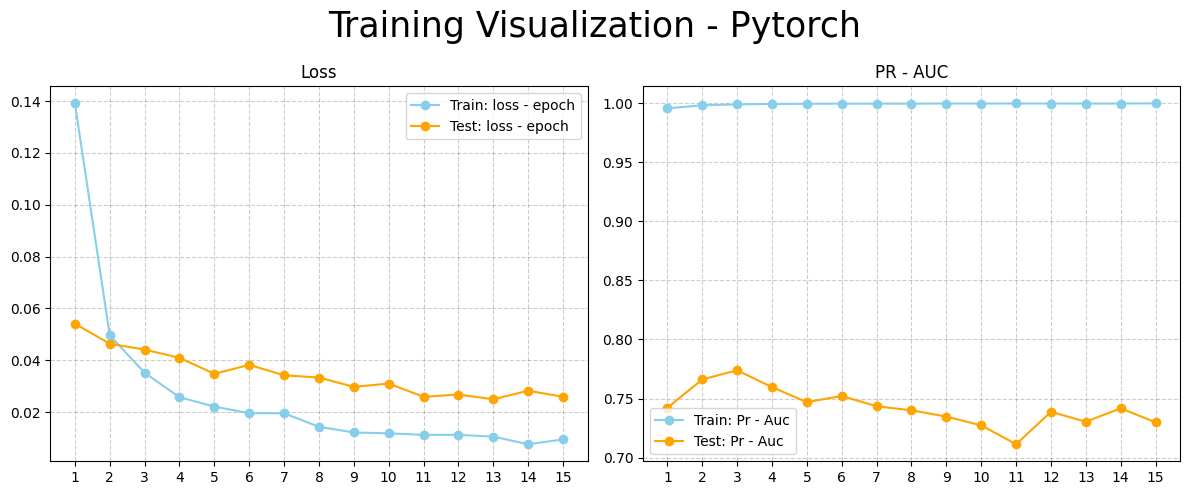

Trực quan hóa kết quả huấn luyện
Tiến hành đánh giá mô hình: 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Độ chính xác mô hình là:  0.998718443874864
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Ma trận nhầm lẫn! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính Classification Report! 
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Đã tính ROC-AUC!
--------------

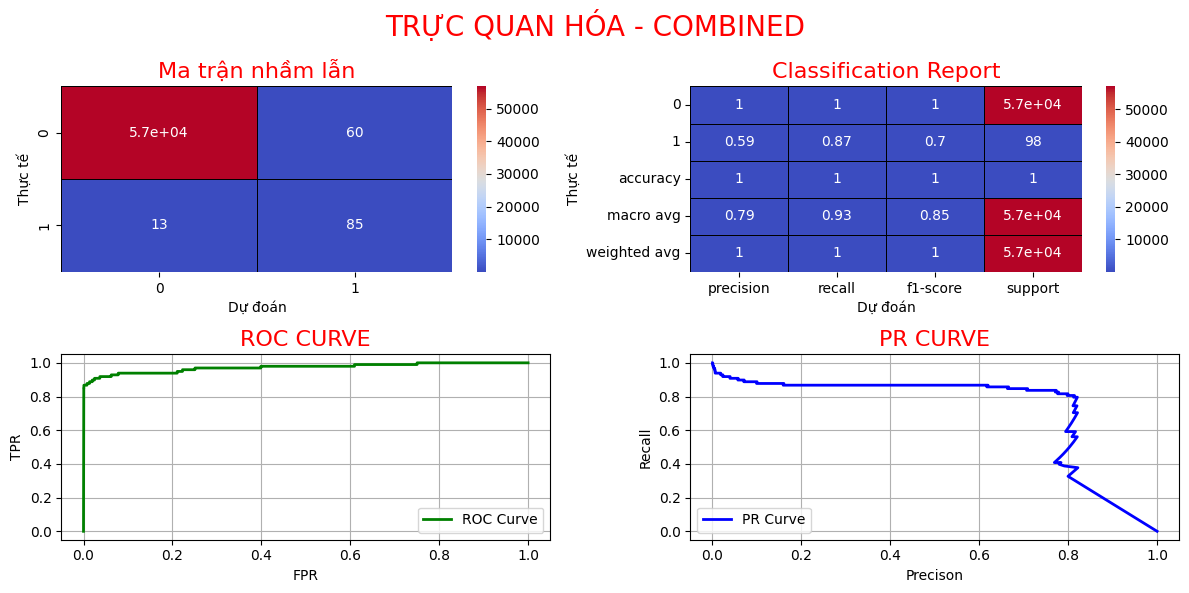

In [98]:
# Thực hành Huấn luyện và đánh giá mô hình

def train_and_evaluate_model(resampled_data, X_test, y_test):
    # Danh sách các phương pháp xử lý mất cân bằng
    resampling_methods = ['original', 'undersampling', 'smote', 'combined']

    # Lưu trữ kết quả
    results = []

    # Huấn luyện và đánh giá mô hình
    for method in resampling_methods:
        print("HUẤN LUYỆN VỚI PHƯƠNG PHÁP XỬ LÝ DỮ LIỆU:", method.upper())
        print("-"*200)

        X_train_resampled, y_train_resampled = resampled_data[method]

        # Huấn luyện mô hình
        y_prob, y_pred = train_model(X_train_resampled, X_test, y_test, y_train_resampled, model = 'Pytorch', num_epochs = 15, threshold = 0.5, verbose = True, Vis = True)

        print('='*200)
        print("Trực quan hóa kết quả huấn luyện")
        print('='*200)
        # Đánh giá mô hình:
        result = eva_and_viz_model(X_test, y_test, y_pred, y_prob, method, show = True)
        results.append(result)
        print('='*200)
        print()

    return results

results_mlp_pytorch = train_and_evaluate_model(resampled_data, X_test, y_test)


1. Mô hình Random Forest trên dữ liệu gốc (chưa cân bằng) là lựa chọn tối ưu nhất trong số các thử nghiệm này. Nó đạt được sự cân bằng tốt giữa việc phát hiện phần lớn các giao dịch gian lận (Recall cao) và cực kỳ hiệu quả trong việc tránh cảnh báo sai các giao dịch hợp lệ (Precision rất cao), điều này cực kỳ quan trọng trong thực tế.

2. Mặc dù các kỹ thuật cân bằng dữ liệu giúp tăng Recall cho các mô hình Logistic Regression và MLP, nhưng cái giá phải trả là sự sụt giảm đáng kể của Precision và tăng False Positive. Điều này cho thấy rằng với bài toán cụ thể và tập dữ liệu này, việc tạo ra dữ liệu tổng hợp (SMOTE) hoặc loại bỏ dữ liệu (Undersampling) có thể làm mất đi các đặc điểm quan trọng giúp phân biệt rõ ràng giữa các lớp, dẫn đến nhiều cảnh báo sai hơn.

3. Nếu buộc phải sử dụng cân bằng dữ liệu, SMOTE có vẻ là phương pháp hiệu quả nhất, đặc biệt cho các mô hình như Logistic Regression và MLP, vì nó duy trì PR-AUC cao hơn và Precision tốt hơn so với Under-sampling và Combined.


In [99]:
def select_best_method_mlp(results):
    print("CHỌN PHƯƠNG PHÁP XỬ LÝ TỐT NHẤT")
    print("-"*100)
    # Truy cập vào từ danh sách từ điển results, truy cập đến key: 'pr_auc'
    # So sánh value của key này, tìm value max
    best_pr_auc = -np.inf
    best_method = None
    for method in results:
        print(f"PR AUC - {method['solu']} : {method['pr_auc']}")
        print('-'*100)
        if method['pr_auc'] > best_pr_auc:
            best_method = method
            best_pr_auc = method['pr_auc']

    print(f"Phương pháp xử lý mất cân bằng tốt nhất cho MLP là: {best_method['solu'].upper()}, với PR_AUC = {best_pr_auc:.4f} ")
    print("-"*100)
    return best_method

best_method = select_best_method_mlp(results_mlp_pytorch)

CHỌN PHƯƠNG PHÁP XỬ LÝ TỐT NHẤT
----------------------------------------------------------------------------------------------------
PR AUC - original : 0.8593953678743051
----------------------------------------------------------------------------------------------------
PR AUC - undersampling : 0.7376233603424939
----------------------------------------------------------------------------------------------------
PR AUC - smote : 0.8101436161329517
----------------------------------------------------------------------------------------------------
PR AUC - combined : 0.7299329291057755
----------------------------------------------------------------------------------------------------
Phương pháp xử lý mất cân bằng tốt nhất cho MLP là: ORIGINAL, với PR_AUC = 0.8594 
----------------------------------------------------------------------------------------------------


### Lựa chọn mô hình tốt nhất

In [100]:
def find_overall_best_model_and_method(all_models_results):
    print("CHỌN MÔ HÌNH VÀ PHƯƠNG PHÁP CÂN BẰNG TỐT NHẤT TỔNG THỂ")
    print("-"*100)

    overall_best_pr_auc = -np.inf
    overall_best_model_name = ""
    overall_best_method_name = ""
    overall_best_result = None # Store the entire result dictionary

    for model_name, results_list in all_models_results.items():
        for result in results_list:
            current_pr_auc = result['pr_auc']
            if current_pr_auc > overall_best_pr_auc:
                overall_best_pr_auc = current_pr_auc
                overall_best_model_name = model_name
                overall_best_method_name = result['solu']
                overall_best_result = result # Store the best result

    print(f"Mô hình tổng thể tốt nhất: {overall_best_model_name}")
    print(f"Với phương pháp cân bằng dữ liệu: {overall_best_method_name.upper()}")
    print(f"Đạt PR-AUC: {overall_best_pr_auc:.4f}")
    if overall_best_result:
        print(f"Precision (Class 1): {overall_best_result['precision_class_1']:.4f}")
        print(f"Recall (Class 1): {overall_best_result['recall_class_1']:.4f}")
        print(f"F1-Score (Class 1): {overall_best_result['f1_score_class_1']:.4f}")
    print("-"*100)

    return overall_best_model_name, overall_best_method_name, overall_best_pr_auc


# Gộp tất cả các kết quả mô hình vào một dictionary
all_models_results = {
    'Logistic Regression': results_lr,
    'Random Forest': results_rf,
    'MLP Pytorch': results_mlp_pytorch
}

# Tìm mô hình và phương pháp tốt nhất tổng thể
best_model, best_balancing_method, best_pr_auc = find_overall_best_model_and_method(all_models_results)


CHỌN MÔ HÌNH VÀ PHƯƠNG PHÁP CÂN BẰNG TỐT NHẤT TỔNG THỂ
----------------------------------------------------------------------------------------------------
Mô hình tổng thể tốt nhất: Random Forest
Với phương pháp cân bằng dữ liệu: SMOTE
Đạt PR-AUC: 0.8699
Precision (Class 1): 0.7434
Recall (Class 1): 0.8571
F1-Score (Class 1): 0.7962
----------------------------------------------------------------------------------------------------


### Tối ưu hóa mô hình

In [101]:
!pip install optuna

[I 2026-03-20 00:42:13,778] A new study created in memory with name: no-name-cce757db-86ac-4a84-8f88-3741ab5fa8ed


TIẾN HÀNH TỐI ƯU HÓA MÔ HÌNH RANDOM FOREST VỚI OPTUNA (PHIÊN BẢN RÚT GỌN)
----------------------------------------------------------------------------------------------------
Kích thước tập huấn luyện sau SMOTE: (250196, 33)
----------------------------------------------------------------------------------------------------
Bắt đầu tìm kiếm siêu tham số (Fast Track - 15 vòng)...


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-03-20 00:44:05,154] Trial 0 finished with value: 0.875610652756875 and parameters: {'n_estimators': 50, 'max_depth': 15, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.875610652756875.
[I 2026-03-20 00:44:49,938] Trial 1 finished with value: 0.7371082410270283 and parameters: {'n_estimators': 50, 'max_depth': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.875610652756875.
[I 2026-03-20 00:46:17,467] Trial 2 finished with value: 0.736379551020059 and parameters: {'n_estimators': 100, 'max_depth': 5, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.875610652756875.
[I 2026-03-20 00:48:59,756] Trial 3 finished with value: 0.8730660688635598 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.875610652756875.
[I 2026-03-20 00:50:22,173] Trial 4 finished with value: 0.8731742519592642 and parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.87561065275687

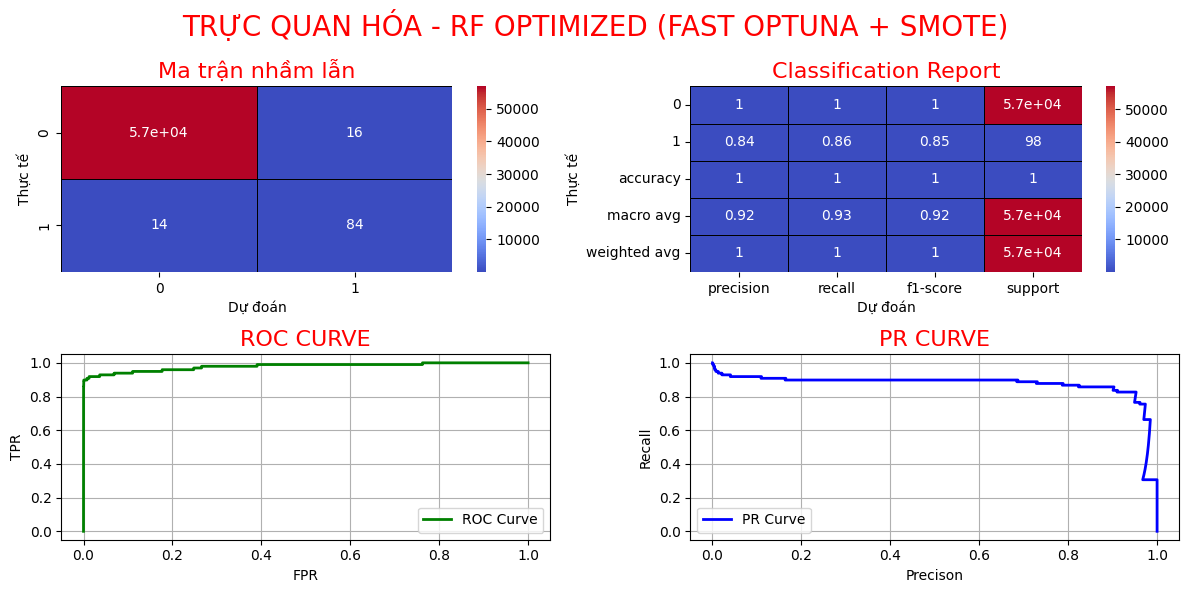


QUÁ TRÌNH TỐI ƯU HÓA HOÀN TẤT!


In [102]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, make_scorer
from collections import Counter
import pandas as pd
import numpy as np

print("TIẾN HÀNH TỐI ƯU HÓA MÔ HÌNH RANDOM FOREST VỚI OPTUNA (PHIÊN BẢN RÚT GỌN)")
print("-"*100)

# 1. Chuẩn bị dữ liệu đã cân bằng bằng SMOTE
X_train_optimized, y_train_optimized = resampled_data['smote']

print(f"Kích thước tập huấn luyện sau SMOTE: {X_train_optimized.shape}")
print("-"*100)

def objective(trial):

    # Dùng suggest_categorical để ép Optuna chỉ chọn 1 trong các số cụ thể, không mò mẫm ở giữa
    n_estimators = trial.suggest_categorical('n_estimators', [50, 100]) # Chỉ xây 50 hoặc 100 cây
    max_depth = trial.suggest_categorical('max_depth', [5, 10, 15])     # Cây bớt sâu để chạy nhanh hơn
    min_samples_leaf = trial.suggest_categorical('min_samples_leaf', [1, 2])

    # Khởi tạo mô hình
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1 # Vẫn huy động tối đa CPU
    )

    # Huấn luyện
    model.fit(X_train_optimized, y_train_optimized)

    # Dự đoán và tính PR-AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_prob)

#Tạo Optuna study
study = optuna.create_study(direction='maximize')

print("Bắt đầu tìm kiếm siêu tham số (Fast Track - 15 vòng)...")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("\nTìm kiếm siêu tham số hoàn tất!")
print("-"*100)

# In kết quả và huấn luyện mô hình chốt hạ
print(f"Siêu tham số tốt nhất: {study.best_params}")
print(f"PR-AUC tốt nhất: {study.best_value:.4f}")
print("-"*100)

best_rf_model_optuna = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf_model_optuna.fit(X_train_optimized, y_train_optimized)

#Đánh giá cuối cùng
print("Đánh giá mô hình Random Forest đã tối ưu:\n")
y_pred_optuna = best_rf_model_optuna.predict(X_test)
y_prob_optuna = best_rf_model_optuna.predict_proba(X_test)[:, 1]

optimized_rf_results_optuna = eva_and_viz_model(
    X_test, y_test, y_pred_optuna, y_prob_optuna,
    name_pp="RF Optimized (Fast Optuna + SMOTE)",
    show=True
)

print("\nQUÁ TRÌNH TỐI ƯU HÓA HOÀN TẤT!")

In [110]:
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
import pandas as pd

def show_best_model_metrics(y_true, y_pred, y_prob, model_name="Mô hình tốt nhất"):
    """
    Hàm tính toán và hiển thị 4 chỉ số quan trọng nhất cho bài toán mất cân bằng.
    """
    print("=" * 60)
    print(f" BÁO CÁO HIỆU NĂNG: {model_name.upper()} ")
    print("=" * 60)

    # Tính toán các chỉ số
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob)

    # Tạo DataFrame để in ra cho đẹp như một bảng
    metrics_df = pd.DataFrame({
        "Chỉ số (Metrics)": ["Precision (Độ chuẩn xác)",
                             "Recall (Độ phủ)",
                             "F1-Score (Điểm cân bằng)",
                             "PR-AUC (Diện tích dưới đường cong PR)"],
        "Điểm số (Score)": [precision, recall, f1, pr_auc]
    })

    # Format điểm số thành 4 chữ số thập phân
    metrics_df['Điểm số (Score)'] = metrics_df['Điểm số (Score)'].apply(lambda x: f"{x:.4f}")

    # In ra bảng
    print(metrics_df.to_string(index=False))
    print("-" * 60)

    # Trả về dictionary phòng trường hợp bạn muốn lưu lại vẽ biểu đồ sau
    return {"Precision": precision, "Recall": recall, "F1": f1, "PR-AUC": pr_auc}
best_metrics = show_best_model_metrics(
y_true=y_test,
y_pred=y_pred_optuna,
y_prob=y_prob_optuna,
model_name="Random Forest + SMOTE (Optuna Tuned)"
)

 BÁO CÁO HIỆU NĂNG: RANDOM FOREST + SMOTE (OPTUNA TUNED) 
                     Chỉ số (Metrics) Điểm số (Score)
             Precision (Độ chuẩn xác)          0.8400
                      Recall (Độ phủ)          0.8571
             F1-Score (Điểm cân bằng)          0.8485
PR-AUC (Diện tích dưới đường cong PR)          0.8756
------------------------------------------------------------


### Lưu mô hình đã tối ưu

In [103]:
import joblib
import os

print("-" * 100)


os.makedirs('saved_models', exist_ok=True)

model_path = 'saved_models/best_rf_model_optuna.pkl'
joblib.dump(best_rf_model_optuna, model_path)

print(f"Đã lưu mô hình thành công tại: {model_path}")
print(f"Kích thước file: {os.path.getsize(model_path) / (1024 * 1024):.2f} MB")

----------------------------------------------------------------------------------------------------
Đã lưu mô hình thành công tại: saved_models/best_rf_model_optuna.pkl
Kích thước file: 3.62 MB


### Tạo file để test

In [104]:
import pandas as pd

# Gộp X_test và y_test lại tạm thời để dễ lọc dữ liệu
test_data = X_test.copy()
test_data['Class'] = y_test

# Trích xuất cố ý: Lấy 10 vụ gian lận và 10 vụ hợp lệ từ tập Test
# Dùng replace=True cho fraud đề phòng tập test của bạn có ít hơn 10 ca gian lận
fraud_samples = test_data[test_data['Class'] == 1].sample(10, random_state=42, replace=True)
normal_samples = test_data[test_data['Class'] == 0].sample(10, random_state=42)

# Nối lại và xáo trộn ngẫu nhiên (tránh việc 10 dòng đầu toàn là gian lận)
demo_data = pd.concat([fraud_samples, normal_samples]).sample(frac=1, random_state=42).reset_index(drop=True)

# Lưu ra file CSV
demo_path = 'fraud_detection_demo_data.csv'
demo_data.to_csv(demo_path, index=False)

print(f" Đã xuất tập dữ liệu Demo thành công tại: {demo_path}")
print("Tập dữ liệu này gồm 20 giao dịch (10 Gian lận, 10 Bình thường) đã được làm sạch.")
print("-" * 100)

 Đã xuất tập dữ liệu Demo thành công tại: fraud_detection_demo_data.csv
Tập dữ liệu này gồm 20 giao dịch (10 Gian lận, 10 Bình thường) đã được làm sạch.
----------------------------------------------------------------------------------------------------
